# Module 5 — Model Development
### Real-time payment fraud detection for an e-commerce platform

**Input:** `features_train.parquet`, `features_test.parquet`, `feature_list.json` from Module 4.

This version trains only the **behavioural** feature set. Full balance-heavy features are not used for model training because they encode PaySim mechanics too directly.

Pipeline:

1. Remove mechanical balance features.
2. Split Module 4 train again into 85% inner-train and 15% validation.
3. Tune each model under four balancing strategies: original, class-weighted, SMOTE, and undersampling.
4. Refit selected hyperparameters on the full Module 4 train set.
5. Evaluate once on the untouched future test set.

Test data is never resampled or augmented.


## Setup & load model-ready data

In [24]:
import sys, json
from pathlib import Path

def _find_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "scripts" / "config.py").exists():
            return cand
    return p
ROOT_GUESS = _find_root(Path.cwd())
if str(ROOT_GUESS) not in sys.path:
    sys.path.insert(0, str(ROOT_GUESS))

from scripts.config import ROOT, DATA_PROCESSED, FIGURES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

REPORTS = ROOT / "Module_08"; MODELS = ROOT / "models"
REPORTS.mkdir(parents=True, exist_ok=True); MODELS.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    p = FIGURES / f"{name}.png"; fig.savefig(p); print(f"figure -> {p.relative_to(ROOT)}")
def save_table(df, name, index=True):
    p = REPORTS / f"{name}.csv"; df.to_csv(p, index=index); print(f"table  -> {p.relative_to(ROOT)}")

meta = json.loads((MODELS / "feature_list.json").read_text())
FEATURES, LABEL = meta["features"], meta["label"]
class_weight = {int(k): v for k, v in meta["class_weight"].items()}

train = pd.read_parquet(DATA_PROCESSED / "features_train.parquet")
test  = pd.read_parquet(DATA_PROCESSED / "features_test.parquet")
X_train, y_train = train[FEATURES], train[LABEL].astype(int)
X_test,  y_test  = test[FEATURES],  test[LABEL].astype(int)
amount_test = test["amount_raw"].to_numpy()   # unscaled $ for the cost model

print(f"train {X_train.shape} fraud={int(y_train.sum())} ({y_train.mean()*100:.3f}%)")
print(f"test  {X_test.shape} fraud={int(y_test.sum())} ({y_test.mean()*100:.3f}%)")
print(f"class_weight from Module 4: {class_weight}")
print(f"total fraud $ at risk in test: {amount_test[y_test.values==1].sum():,.0f}")

train (2217905, 46) fraud=3955 (0.178%)
test  (552504, 46) fraud=4258 (0.771%)
class_weight from Module 4: {0: 0.5009, 1: 280.3925}
total fraud $ at risk in test: 6,702,594,765


## 1. Behavioural feature set only

**Reasoning.** PaySim balance fields can make the full model look unrealistically strong.
For the deployable modelling path we therefore remove mechanical balance/amount features
and train only on behavioural/contextual signals: device, geo, velocity, timing, failed
attempts, and encoded countries.

The full feature set is no longer trained in Module 5. If we need full-feature numbers,
they should remain diagnostic only, not part of model selection.


In [25]:
MECHANICAL = [
    "orig_balance_err", "dest_balance_err", "drained_origin",
    "amount_to_oldbalanceOrg", "dest_balances_masked",
    "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest",
    "amount", "log_amount",
]
MECHANICAL = [c for c in MECHANICAL if c in FEATURES]
BEHAVIOURAL = [c for c in FEATURES if c not in MECHANICAL]

MODEL_FEATURES = BEHAVIOURAL
print(f"all features       : {len(FEATURES)}")
print(f"removed mechanical : {len(MECHANICAL)} -> {MECHANICAL}")
print(f"behavioural used   : {len(MODEL_FEATURES)}")

feature_set_table = pd.DataFrame({
    "feature": FEATURES,
    "used_for_training": [c in MODEL_FEATURES for c in FEATURES],
    "reason": ["behavioural/contextual" if c in MODEL_FEATURES else "removed mechanical PaySim balance/amount signal" for c in FEATURES],
})
display(feature_set_table)
save_table(feature_set_table, "m5_behavioural_feature_set", index=False)


all features       : 46
removed mechanical : 9 -> ['dest_balance_err', 'drained_origin', 'amount_to_oldbalanceOrg', 'dest_balances_masked', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'amount', 'log_amount']
behavioural used   : 37


,feature,used_for_training,reason
0,step,True,behavioural/contextual
1,amount,False,removed mechanical PaySim balance/amount signal
2,oldbalanceOrg,False,removed mechanical PaySim balance/amount signal
3,newbalanceOrig,False,removed mechanical PaySim balance/amount signal
4,oldbalanceDest,False,removed mechanical PaySim balance/amount signal
5,account_age_days,True,behavioural/contextual
6,is_new_device,True,behavioural/contextual
7,shipping_billing_mismatch,True,behavioural/contextual
8,failed_payment_attempts,True,behavioural/contextual
9,ip_billing_distance_km,True,behavioural/contextual


table  -> Module_08/m5_behavioural_feature_set.csv


## 2. Train three classifiers under four balancing strategies

We compare three model families:

- Logistic Regression
- Random Forest
- LightGBM

For each model, we evaluate four training data strategies:

- `original`: no balancing, no class weights
- `class_weighted`: original rows, weighted loss
- `smote`: SMOTE applied to the training fold only
- `undersampling`: majority undersampling applied to the training fold only

The validation fold and test fold are always left untouched.


## 2b. Hyperparameter tuning on the 85/15 train-validation split

Module 4 already created the temporal train/test split. Inside the Module 4 train set,
we split again:

- 85% inner-train: fit balancing method + train candidates
- 15% validation: evaluate candidates and choose hyperparameters

For SMOTE and undersampling, resampling happens **only on the 85% inner-train fold**.
The 15% validation fold remains at the real validation distribution.

Selection objective:

`net_cost = missed_fraud_amount + C_FP × false_positives`

`C_FP = 10` is the original notebook's review/friction assumption. Lower net cost is better.
AUC-PR is still reported separately as ranking quality.


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import lightgbm as lgb
import gc

INNER_VAL_FRAC = 0.15
TUNE_MAX_TRAIN_ROWS = 250_000
TUNE_RANDOM_STATE = 42
TUNE_N_JOBS = 8
C_FP = 10.0
MIN_OPERATING_THRESHOLD = 0.0005
SMOTE_TARGET_RATIO = 0.05
UNDER_TARGET_RATIO = 0.05
BALANCING_METHODS = ['original', 'class_weighted', 'smote', 'undersampling']
MODEL_NAMES = ['LogisticRegression', 'RandomForest', 'LightGBM']


def temporal_train_val_split(df, label, val_frac=0.15, seed=42):
    if 'step_raw' in df.columns:
        cut = df['step_raw'].quantile(1 - val_frac)
        tr = df[df['step_raw'] <= cut].reset_index(drop=True)
        va = df[df['step_raw'] > cut].reset_index(drop=True)
        if tr[label].nunique() == 2 and va[label].nunique() == 2:
            return tr, va, f'temporal_by_step_raw <= {cut:.0f}'
    tr_idx, va_idx = train_test_split(
        df.index, test_size=val_frac, random_state=seed, stratify=df[label]
    )
    return df.loc[tr_idx].reset_index(drop=True), df.loc[va_idx].reset_index(drop=True), 'stratified_random_fallback'


def stratified_cap_df(df, label, max_rows, seed=42):
    if not max_rows or len(df) <= max_rows:
        return df.reset_index(drop=True)
    frac = max_rows / len(df)
    return (
        df.groupby(label, group_keys=False)
        .sample(frac=frac, random_state=seed)
        .reset_index(drop=True)
    )


def compact_config_label(model_name, params):
    p = dict(params)
    if model_name == 'LogisticRegression':
        return f"C={p.get('C')}"
    if model_name == 'RandomForest':
        return f"trees={p.get('n_estimators')}, depth={p.get('max_depth')}, leaf={p.get('min_samples_leaf')}"
    if model_name == 'LightGBM':
        return f"trees={p.get('n_estimators')}, lr={p.get('learning_rate')}, leaves={p.get('num_leaves')}, child={p.get('min_child_samples')}"
    return str(p)


def logistic_candidates():
    return [
        {'C': C, 'solver': 'lbfgs', 'max_iter': 1500, 'n_jobs': TUNE_N_JOBS}
        for C in [0.03, 0.1, 0.3, 1.0, 3.0]
    ]


def rf_candidates():
    return [
        {'n_estimators': 50,  'max_depth': 8,  'min_samples_leaf': 100, 'max_features': 'sqrt', 'n_jobs': TUNE_N_JOBS, 'random_state': 42},
        {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 50,  'max_features': 'sqrt', 'n_jobs': TUNE_N_JOBS, 'random_state': 42},
        {'n_estimators': 200, 'max_depth': 16, 'min_samples_leaf': 20,  'max_features': 'sqrt', 'n_jobs': TUNE_N_JOBS, 'random_state': 42},
        {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 20,  'max_features': 'sqrt', 'n_jobs': TUNE_N_JOBS, 'random_state': 42},
        {'n_estimators': 100, 'max_depth': 16, 'min_samples_leaf': 100, 'max_features': 0.7,    'n_jobs': TUNE_N_JOBS, 'random_state': 42},
        {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 100, 'max_features': 0.7,    'n_jobs': TUNE_N_JOBS, 'random_state': 42},
        {'n_estimators': 200, 'max_depth': 16, 'min_samples_leaf': 50,  'max_features': 0.7,    'n_jobs': TUNE_N_JOBS, 'random_state': 42},
        {'n_estimators': 300, 'max_depth': 16, 'min_samples_leaf': 50,  'max_features': 'sqrt', 'n_jobs': TUNE_N_JOBS, 'random_state': 42},
    ]


def lgbm_candidates():
    base = {'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': TUNE_N_JOBS, 'verbose': -1}
    configs = [
        {'n_estimators': 100, 'learning_rate': 0.05, 'num_leaves': 15, 'min_child_samples': 200, 'reg_lambda': 10.0},
        {'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 15, 'min_child_samples': 200, 'reg_lambda': 10.0},
        {'n_estimators': 300, 'learning_rate': 0.03, 'num_leaves': 31, 'min_child_samples': 200, 'reg_lambda': 10.0},
        {'n_estimators': 600, 'learning_rate': 0.03, 'num_leaves': 31, 'min_child_samples': 200, 'reg_lambda': 10.0},
        {'n_estimators': 300, 'learning_rate': 0.03, 'num_leaves': 63, 'min_child_samples': 300, 'reg_lambda': 10.0},
        {'n_estimators': 600, 'learning_rate': 0.03, 'num_leaves': 15, 'min_child_samples': 300, 'reg_lambda': 5.0},
        {'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 100, 'reg_lambda': 10.0},
        {'n_estimators': 600, 'learning_rate': 0.03, 'num_leaves': 63, 'min_child_samples': 300, 'reg_lambda': 20.0},
    ]
    return [{**base, **cfg} for cfg in configs]


def candidate_list(model_name):
    if model_name == 'LogisticRegression':
        return logistic_candidates()
    if model_name == 'RandomForest':
        return rf_candidates()
    if model_name == 'LightGBM':
        return lgbm_candidates()
    raise ValueError(model_name)


def apply_balancing(X, y, method, seed=42):
    if method in {'original', 'class_weighted'}:
        return X, y
    if method == 'smote':
        sm = SMOTE(random_state=seed, k_neighbors=5, sampling_strategy=SMOTE_TARGET_RATIO)
        return sm.fit_resample(X, y)
    if method == 'undersampling':
        rus = RandomUnderSampler(random_state=seed, sampling_strategy=UNDER_TARGET_RATIO)
        return rus.fit_resample(X, y)
    raise ValueError(method)


def model_params_for_balancing(model_name, base_params, method, y_fit):
    params = dict(base_params)
    if method == 'class_weighted':
        if model_name in {'LogisticRegression', 'RandomForest'}:
            params['class_weight'] = 'balanced'
        elif model_name == 'LightGBM':
            pos = int(np.sum(y_fit == 1))
            neg = int(np.sum(y_fit == 0))
            params['scale_pos_weight'] = neg / max(pos, 1)
    return params


def make_candidate_model(model_name, params):
    if model_name == 'LogisticRegression':
        return LogisticRegression(**params)
    if model_name == 'RandomForest':
        return RandomForestClassifier(**params)
    if model_name == 'LightGBM':
        return lgb.LGBMClassifier(**params)
    raise ValueError(model_name)


def sweep_costs(y_true, score, amount, c_fp=C_FP, grid=None):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    amount = np.asarray(amount, dtype=float)
    if grid is None:
        grid = np.r_[np.linspace(MIN_OPERATING_THRESHOLD, 0.05, 100), np.linspace(0.055, 1.0, 190)]
    rows = []
    for threshold in grid:
        pred = score >= threshold
        fn = (y_true == 1) & (~pred)
        fp = (y_true == 0) & pred
        tp = (y_true == 1) & pred
        net_cost = amount[fn].sum() + c_fp * fp.sum()
        rows.append({
            'threshold': float(threshold),
            'net_cost': float(net_cost),
            'missed_fraud_amount': float(amount[fn].sum()),
            'fraud_amount_caught': float(amount[tp].sum()),
            'n_fp': int(fp.sum()),
            'n_tp': int(tp.sum()),
            'n_fn': int(fn.sum()),
        })
    return pd.DataFrame(rows)


def evaluate_candidate(model, X_tr, y_tr, X_va, y_va, amount_va):
    model.fit(X_tr, y_tr)
    score = model.predict_proba(X_va)[:, 1]
    sweep = sweep_costs(y_va, score, amount_va)
    admissible = sweep[
        (sweep['threshold'] >= MIN_OPERATING_THRESHOLD)
        & ((sweep['n_fp'] + sweep['n_tp']) < len(y_va))
    ]
    if admissible.empty:
        raise ValueError('No admissible positive threshold; review-all is not allowed')
    best = admissible.sort_values(['net_cost', 'n_fp'], ascending=[True, True]).iloc[0]
    pred = score >= best['threshold']
    return {
        'val_auc_pr': average_precision_score(y_va, score),
        'val_roc_auc': roc_auc_score(y_va, score),
        'val_threshold': float(best['threshold']),
        'val_precision': precision_score(y_va, pred, zero_division=0),
        'val_recall': recall_score(y_va, pred, zero_division=0),
        'val_f1': f1_score(y_va, pred, zero_division=0),
        'val_net_cost': float(best['net_cost']),
        'val_missed_fraud_amount': float(best['missed_fraud_amount']),
        'val_fraud_amount_caught': float(best['fraud_amount_caught']),
        'val_n_fp': int(best['n_fp']),
        'val_n_tp': int(best['n_tp']),
        'val_n_fn': int(best['n_fn']),
    }


tune_train_raw, tune_val, tune_split_method = temporal_train_val_split(train, LABEL, val_frac=INNER_VAL_FRAC, seed=TUNE_RANDOM_STATE)
tune_train = stratified_cap_df(tune_train_raw, LABEL, TUNE_MAX_TRAIN_ROWS, TUNE_RANDOM_STATE)

X_va = tune_val[MODEL_FEATURES]
y_va = tune_val[LABEL].astype(int)
amount_va = tune_val['amount_raw'].to_numpy(dtype=float)

split_summary = pd.DataFrame([
    {'split': 'inner_train_85_raw', 'rows': len(tune_train_raw), 'fraud_rows': int(tune_train_raw[LABEL].sum()), 'fraud_rate_%': tune_train_raw[LABEL].mean() * 100},
    {'split': 'inner_train_85_sample_used_for_tuning', 'rows': len(tune_train), 'fraud_rows': int(tune_train[LABEL].sum()), 'fraud_rate_%': tune_train[LABEL].mean() * 100},
    {'split': 'validation_15_untouched', 'rows': len(tune_val), 'fraud_rows': int(tune_val[LABEL].sum()), 'fraud_rate_%': tune_val[LABEL].mean() * 100},
])
print('inner train/validation split:', tune_split_method)
display(split_summary.style.format({'fraud_rate_%': '{:.4f}'}))
save_table(split_summary, 'm5_tuning_train_val_split', index=False)

rows = []
TUNED_MODEL_PARAMS = {}
for method in BALANCING_METHODS:
    X_base = tune_train[MODEL_FEATURES]
    y_base = tune_train[LABEL].astype(int)
    X_bal, y_bal = apply_balancing(X_base, y_base, method, seed=TUNE_RANDOM_STATE)
    print(f"\nBalancing={method}: train rows {len(y_base):,} -> {len(y_bal):,}; fraud={int(np.sum(y_bal == 1)):,} ({np.mean(y_bal == 1)*100:.3f}%)")
    for model_name in MODEL_NAMES:
        for idx, base_params in enumerate(candidate_list(model_name), start=1):
            params = model_params_for_balancing(model_name, base_params, method, y_base)
            config_label = compact_config_label(model_name, base_params)
            print(f"tuning {method:14s} | {model_name:18s} | {config_label}")
            model = make_candidate_model(model_name, params)
            metrics = evaluate_candidate(model, X_bal, y_bal, X_va, y_va, amount_va)
            row = {
                'data_balancing': method,
                'model': model_name,
                'config_id': f'{method}_{model_name}_{idx:02d}',
                'config_label': config_label,
                'params_json': json.dumps(params, default=float),
                'inner_train_rows_after_balancing': len(y_bal),
                'inner_train_fraud_after_balancing': int(np.sum(y_bal == 1)),
                'validation_rows': len(y_va),
                'c_fp_assumption': C_FP,
            }
            row.update(metrics)
            rows.append(row)
            del model
            gc.collect()

tuning_results = pd.DataFrame(rows)
tuning_results = tuning_results.sort_values(['data_balancing', 'model', 'val_net_cost', 'val_auc_pr'], ascending=[True, True, True, False])
tuning_results.to_csv(REPORTS / 'm5_hyperparameter_tuning_results.csv', index=False)

valid_tuning_results = tuning_results[
    tuning_results['val_threshold'] >= MIN_OPERATING_THRESHOLD
].copy()
best_tuning = (valid_tuning_results
    .sort_values(['data_balancing', 'model', 'val_net_cost', 'val_auc_pr'], ascending=[True, True, True, False])
    .groupby(['data_balancing', 'model'], as_index=False)
    .head(1)
    .reset_index(drop=True))
for _, row in best_tuning.iterrows():
    TUNED_MODEL_PARAMS[(row['data_balancing'], row['model'])] = json.loads(row['params_json'])
best_tuning.to_csv(REPORTS / 'm5_hyperparameter_tuning_best.csv', index=False)

val_aucpr_table = tuning_results[['data_balancing', 'model', 'config_label', 'val_auc_pr']].copy()
val_netcost_table = tuning_results[['data_balancing', 'model', 'config_label', 'val_net_cost']].copy()
save_table(val_aucpr_table, 'm5_tuning_validation_auc_pr', index=False)
save_table(val_netcost_table, 'm5_tuning_validation_net_cost', index=False)

print('Best validation config per balancing method and model:')
display(best_tuning[['data_balancing', 'model', 'config_label', 'val_net_cost', 'val_auc_pr', 'val_threshold', 'val_precision', 'val_recall', 'val_f1', 'val_n_fp', 'val_n_tp', 'val_n_fn']].style.format({
    'val_net_cost': '{:,.0f}',
    'val_auc_pr': '{:.4f}',
    'val_threshold': '{:.4f}',
    'val_precision': '{:.4f}',
    'val_recall': '{:.4f}',
    'val_f1': '{:.4f}',
}))


inner train/validation split: temporal_by_step_raw <= 307


,split,rows,fraud_rows,fraud_rate_%
0,inner_train_85_raw,1889936,3471,0.1837
1,inner_train_85_sample_used_for_tuning,250000,459,0.1836
2,validation_15_untouched,327969,484,0.1476


table  -> Module_08/m5_tuning_train_val_split.csv

Balancing=original: train rows 250,000 -> 250,000; fraud=459 (0.184%)
tuning original       | LogisticRegression | C=0.03


/home/phucnt/miniconda3/envs/BA/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=8', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


tuning original       | LogisticRegression | C=0.1


...

/home/phucnt/miniconda3/envs/BA/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=8', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


tuning undersampling  | LogisticRegression | C=3.0


/home/phucnt/miniconda3/envs/BA/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=8', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


tuning undersampling  | RandomForest       | trees=50, depth=8, leaf=100
tuning undersampling  | RandomForest       | trees=100, depth=12, leaf=50
tuning undersampling  | RandomForest       | trees=200, depth=16, leaf=20
tuning undersampling  | RandomForest       | trees=200, depth=20, leaf=20
tuning undersampling  | RandomForest       | trees=100, depth=16, leaf=100
tuning undersampling  | RandomForest       | trees=200, depth=12, leaf=100
tuning undersampling  | RandomForest       | trees=200, depth=16, leaf=50
tuning undersampling  | RandomForest       | trees=300, depth=16, leaf=50
tuning undersampling  | LightGBM           | trees=100, lr=0.05, leaves=15, child=200
tuning undersampling  | LightGBM           | trees=300, lr=0.05, leaves=15, child=200
tuning undersampling  | LightGBM           | trees=300, lr=0.03, leaves=31, child=200
tuning undersampling  | LightGBM           | trees=600, lr=0.03, leaves=31, child=200
tuning undersampling  | LightGBM           | trees=300, lr=0.03

,data_balancing,model,config_label,val_net_cost,val_auc_pr,val_threshold,val_precision,val_recall,val_f1,val_n_fp,val_n_tp,val_n_fn
0,class_weighted,LightGBM,"trees=100, lr=0.05, leaves=15, child=200","33,510,587",0.0707,0.0010,0.0106,0.9050,0.0210,40774,438,46
1,class_weighted,LogisticRegression,C=3.0,"1,057,192",0.7447,0.0055,0.0046,0.9979,0.0091,104698,483,1
2,class_weighted,RandomForest,"trees=50, depth=8, leaf=100","1,188,887",0.6800,0.0480,0.0046,0.9979,0.0092,103528,483,1
3,original,LightGBM,"trees=100, lr=0.05, leaves=15, child=200","9,919,116",0.7905,0.0005,0.0159,0.9814,0.0312,29485,475,9
4,original,LogisticRegression,C=0.03,"2,350,699",0.7388,0.0005,0.0081,0.9897,0.0161,58396,479,5
5,original,RandomForest,"trees=300, depth=16, leaf=50","2,979,885",0.6495,0.0005,0.0084,0.9917,0.0167,56517,480,4
6,smote,LightGBM,"trees=100, lr=0.05, leaves=15, child=200","1,190,742",0.7487,0.0015,0.0041,0.9979,0.0081,118053,483,1
7,smote,LogisticRegression,C=0.03,"1,440,103",0.7275,0.0010,0.0044,0.9938,0.0087,109794,481,3
8,smote,RandomForest,"trees=200, depth=16, leaf=20","1,052,627",0.7163,0.0015,0.0053,0.9979,0.0106,89902,483,1
9,undersampling,LightGBM,"trees=300, lr=0.05, leaves=31, child=100","806,791",0.7515,0.0025,0.0106,0.9917,0.0209,44945,480,4


figure -> Module_08/figures/m5_tuning_original_logisticregression_val_auc_pr.png


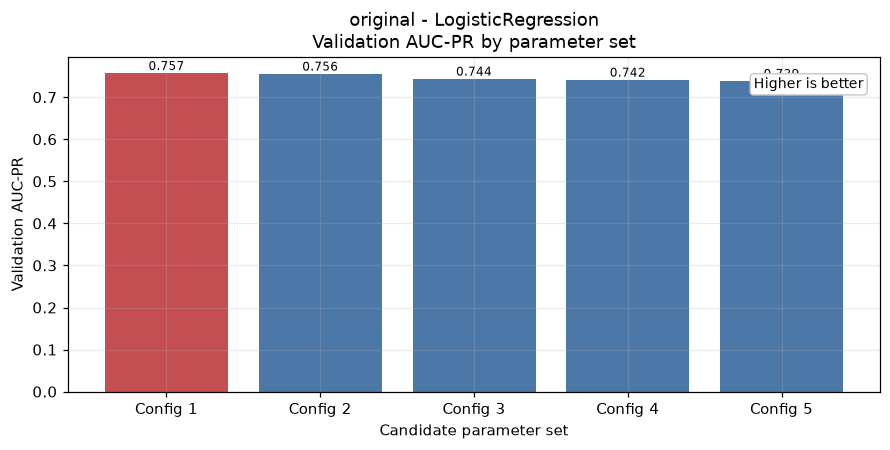

original - LogisticRegression: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,C=0.3,0.7574,"9,540,894",0.0005,0.0171,0.9793,27235,474,10
1,C=0.1,0.7559,"8,846,573",0.0005,0.0140,0.9855,33611,477,7
2,C=3.0,0.7441,"26,675,079",0.0005,0.0179,0.9669,25670,468,16
3,C=1.0,0.7417,"17,094,712",0.0005,0.0189,0.9711,24393,470,14
4,C=0.03,0.7388,"2,350,699",0.0005,0.0081,0.9897,58396,479,5


figure -> Module_08/figures/m5_tuning_original_logisticregression_val_net_cost.png


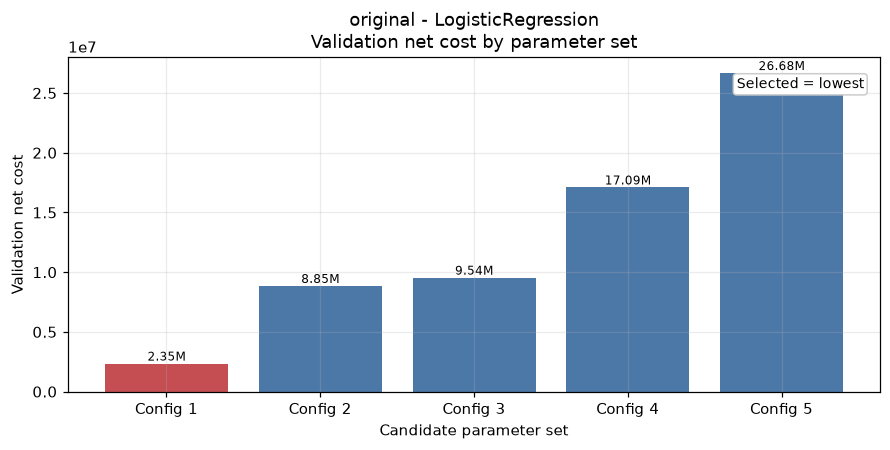

original - LogisticRegression: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,C=0.03,0.7388,"2,350,699",0.0005,0.0081,0.9897,58396,479,5
1,C=0.1,0.7559,"8,846,573",0.0005,0.0140,0.9855,33611,477,7
2,C=0.3,0.7574,"9,540,894",0.0005,0.0171,0.9793,27235,474,10
3,C=1.0,0.7417,"17,094,712",0.0005,0.0189,0.9711,24393,470,14
4,C=3.0,0.7441,"26,675,079",0.0005,0.0179,0.9669,25670,468,16


figure -> Module_08/figures/m5_tuning_original_randomforest_val_auc_pr.png


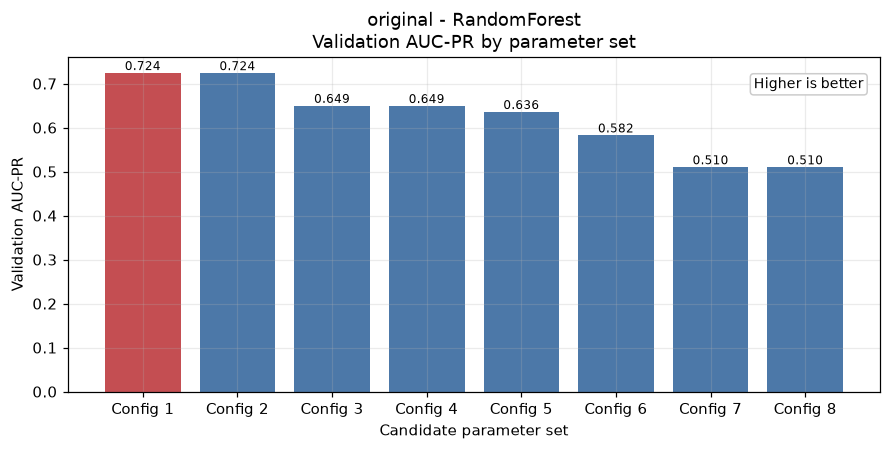

original - RandomForest: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=200, depth=16, leaf=20",0.7241,"10,144,669",0.0005,0.0090,0.9876,52386,478,6
1,"trees=200, depth=20, leaf=20",0.7239,"11,198,183",0.0010,0.0134,0.9793,34860,474,10
2,"trees=300, depth=16, leaf=50",0.6495,"2,979,885",0.0005,0.0084,0.9917,56517,480,4
3,"trees=100, depth=12, leaf=50",0.6491,"9,576,703",0.0005,0.0086,0.9897,55067,479,5
4,"trees=50, depth=8, leaf=100",0.6355,"3,069,915",0.0005,0.0073,0.9917,65520,480,4
5,"trees=200, depth=16, leaf=50",0.5823,"11,990,825",0.0005,0.0171,0.9731,27104,471,13
6,"trees=200, depth=12, leaf=100",0.5099,"11,725,869",0.0005,0.0148,0.9731,31428,471,13
7,"trees=100, depth=16, leaf=100",0.5099,"11,476,488",0.0010,0.0200,0.9752,23117,472,12


figure -> Module_08/figures/m5_tuning_original_randomforest_val_net_cost.png


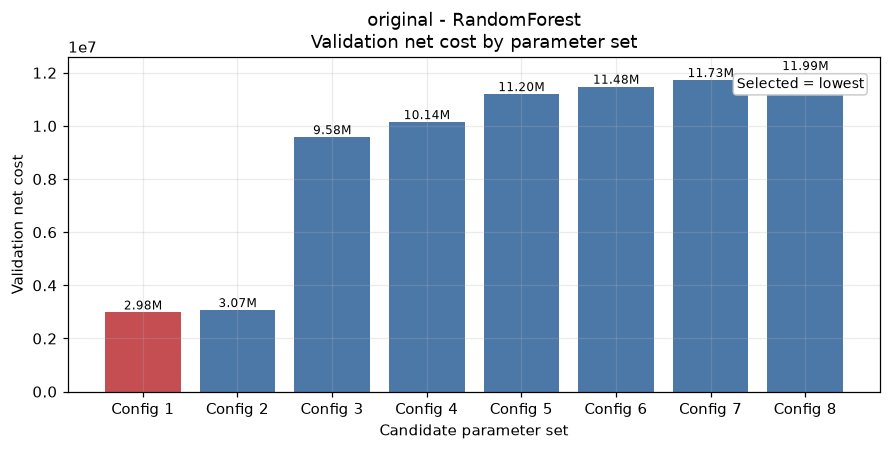

original - RandomForest: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=300, depth=16, leaf=50",0.6495,"2,979,885",0.0005,0.0084,0.9917,56517,480,4
1,"trees=50, depth=8, leaf=100",0.6355,"3,069,915",0.0005,0.0073,0.9917,65520,480,4
2,"trees=100, depth=12, leaf=50",0.6491,"9,576,703",0.0005,0.0086,0.9897,55067,479,5
3,"trees=200, depth=16, leaf=20",0.7241,"10,144,669",0.0005,0.0090,0.9876,52386,478,6
4,"trees=200, depth=20, leaf=20",0.7239,"11,198,183",0.0010,0.0134,0.9793,34860,474,10
5,"trees=100, depth=16, leaf=100",0.5099,"11,476,488",0.0010,0.0200,0.9752,23117,472,12
6,"trees=200, depth=12, leaf=100",0.5099,"11,725,869",0.0005,0.0148,0.9731,31428,471,13
7,"trees=200, depth=16, leaf=50",0.5823,"11,990,825",0.0005,0.0171,0.9731,27104,471,13


figure -> Module_08/figures/m5_tuning_original_lightgbm_val_auc_pr.png


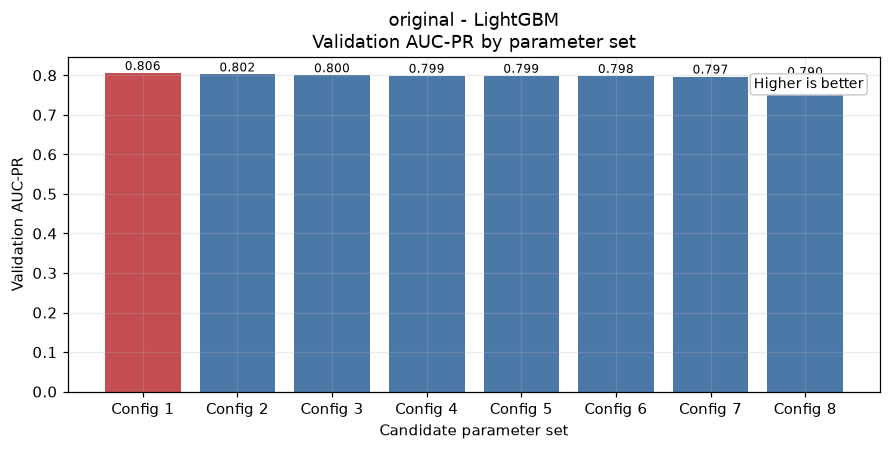

original - LightGBM: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=300, lr=0.05, leaves=15, child=200",0.8057,"25,459,883",0.0005,0.0293,0.9711,15562,470,14
1,"trees=300, lr=0.05, leaves=31, child=100",0.8022,"19,439,720",0.0005,0.0362,0.9711,12505,470,14
2,"trees=300, lr=0.03, leaves=31, child=200",0.8000,"11,404,140",0.0005,0.0262,0.9773,17603,473,11
3,"trees=600, lr=0.03, leaves=63, child=300",0.7988,"11,454,503",0.0005,0.0322,0.9752,14208,472,12
4,"trees=600, lr=0.03, leaves=15, child=300",0.7986,"26,869,057",0.0005,0.0508,0.9628,8713,466,18
5,"trees=600, lr=0.03, leaves=31, child=200",0.7982,"26,327,016",0.0005,0.0433,0.9669,10349,468,16
6,"trees=300, lr=0.03, leaves=63, child=300",0.7966,"11,488,113",0.0005,0.0262,0.9752,17569,472,12
7,"trees=100, lr=0.05, leaves=15, child=200",0.7905,"9,919,116",0.0005,0.0159,0.9814,29485,475,9


figure -> Module_08/figures/m5_tuning_original_lightgbm_val_net_cost.png


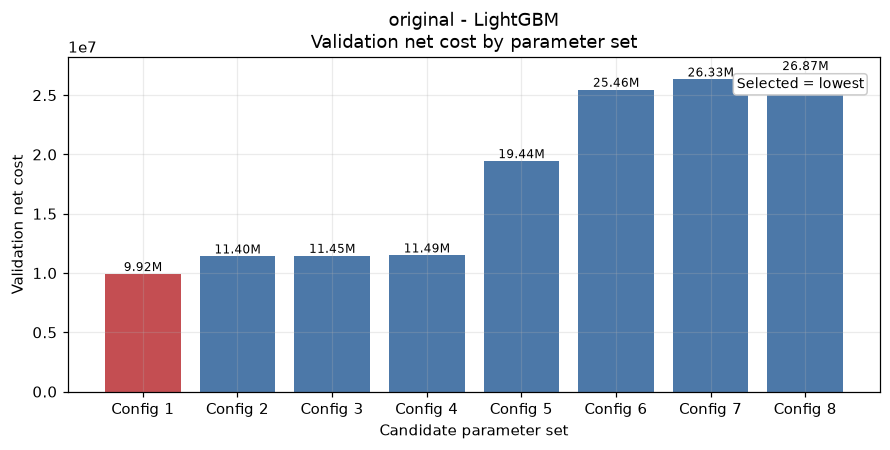

original - LightGBM: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=100, lr=0.05, leaves=15, child=200",0.7905,"9,919,116",0.0005,0.0159,0.9814,29485,475,9
1,"trees=300, lr=0.03, leaves=31, child=200",0.8000,"11,404,140",0.0005,0.0262,0.9773,17603,473,11
2,"trees=600, lr=0.03, leaves=63, child=300",0.7988,"11,454,503",0.0005,0.0322,0.9752,14208,472,12
3,"trees=300, lr=0.03, leaves=63, child=300",0.7966,"11,488,113",0.0005,0.0262,0.9752,17569,472,12
4,"trees=300, lr=0.05, leaves=31, child=100",0.8022,"19,439,720",0.0005,0.0362,0.9711,12505,470,14
5,"trees=300, lr=0.05, leaves=15, child=200",0.8057,"25,459,883",0.0005,0.0293,0.9711,15562,470,14
6,"trees=600, lr=0.03, leaves=31, child=200",0.7982,"26,327,016",0.0005,0.0433,0.9669,10349,468,16
7,"trees=600, lr=0.03, leaves=15, child=300",0.7986,"26,869,057",0.0005,0.0508,0.9628,8713,466,18


figure -> Module_08/figures/m5_tuning_class_weighted_logisticregression_val_auc_pr.png


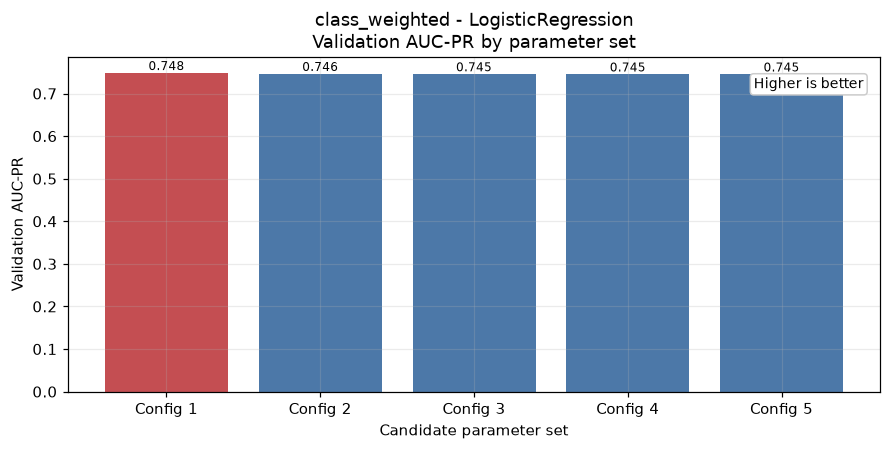

class_weighted - LogisticRegression: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,C=0.03,0.7482,"1,107,242",0.0065,0.0044,0.9979,109703,483,1
1,C=0.1,0.7460,"1,088,802",0.0055,0.0045,0.9979,107859,483,1
2,C=0.3,0.7453,"1,067,152",0.0055,0.0045,0.9979,105694,483,1
3,C=1.0,0.7448,"1,058,482",0.0055,0.0046,0.9979,104827,483,1
4,C=3.0,0.7447,"1,057,192",0.0055,0.0046,0.9979,104698,483,1


figure -> Module_08/figures/m5_tuning_class_weighted_logisticregression_val_net_cost.png


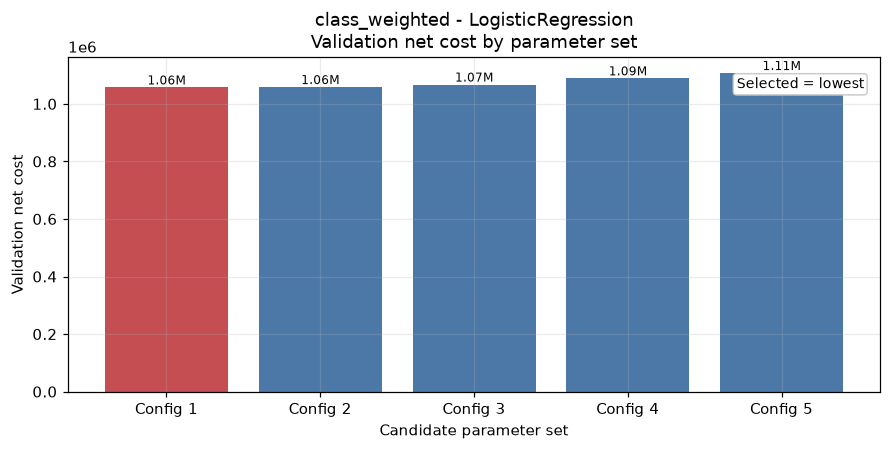

class_weighted - LogisticRegression: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,C=3.0,0.7447,"1,057,192",0.0055,0.0046,0.9979,104698,483,1
1,C=1.0,0.7448,"1,058,482",0.0055,0.0046,0.9979,104827,483,1
2,C=0.3,0.7453,"1,067,152",0.0055,0.0045,0.9979,105694,483,1
3,C=0.1,0.7460,"1,088,802",0.0055,0.0045,0.9979,107859,483,1
4,C=0.03,0.7482,"1,107,242",0.0065,0.0044,0.9979,109703,483,1


figure -> Module_08/figures/m5_tuning_class_weighted_randomforest_val_auc_pr.png


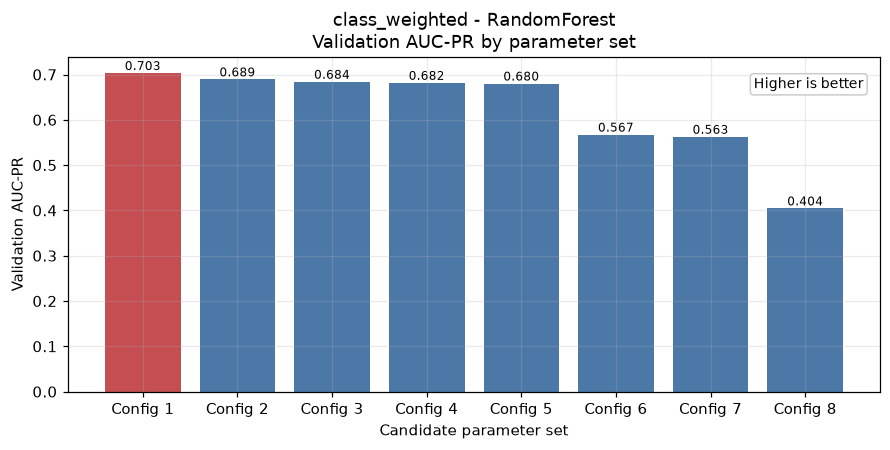

class_weighted - RandomForest: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=300, depth=16, leaf=50",0.7033,"1,623,781",0.0080,0.0037,0.9959,129183,482,2
1,"trees=200, depth=20, leaf=20",0.6893,"1,849,247",0.0005,0.0028,0.9979,169564,483,1
2,"trees=200, depth=16, leaf=20",0.6840,"1,352,637",0.0045,0.0040,0.9979,119903,483,1
3,"trees=100, depth=12, leaf=50",0.6816,"1,507,371",0.0105,0.0041,0.9959,117542,482,2
4,"trees=50, depth=8, leaf=100",0.6800,"1,188,887",0.0480,0.0046,0.9979,103528,483,1
5,"trees=100, depth=16, leaf=100",0.5673,"3,082,755",0.0095,0.0082,0.9917,57786,480,4
6,"trees=200, depth=12, leaf=100",0.5625,"2,924,557",0.0030,0.0060,0.9938,79819,481,3
7,"trees=200, depth=16, leaf=50",0.4045,"3,422,024",0.0130,0.0130,0.9855,36077,477,7


figure -> Module_08/figures/m5_tuning_class_weighted_randomforest_val_net_cost.png


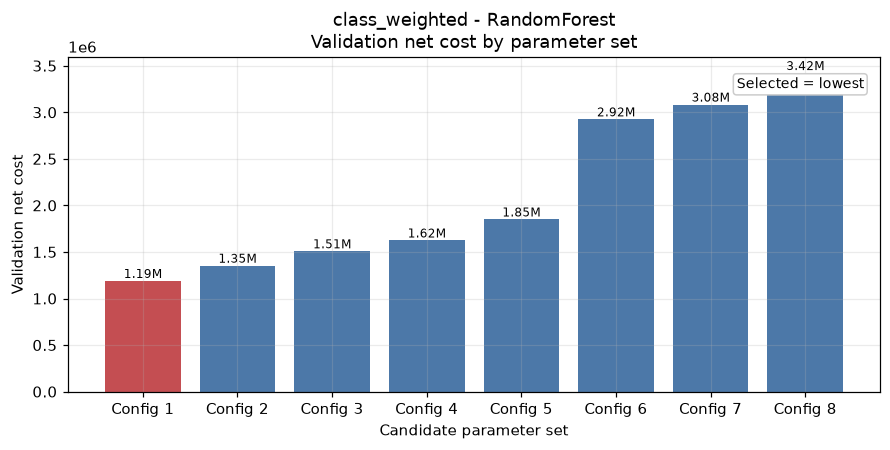

class_weighted - RandomForest: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=50, depth=8, leaf=100",0.6800,"1,188,887",0.0480,0.0046,0.9979,103528,483,1
1,"trees=200, depth=16, leaf=20",0.6840,"1,352,637",0.0045,0.0040,0.9979,119903,483,1
2,"trees=100, depth=12, leaf=50",0.6816,"1,507,371",0.0105,0.0041,0.9959,117542,482,2
3,"trees=300, depth=16, leaf=50",0.7033,"1,623,781",0.0080,0.0037,0.9959,129183,482,2
4,"trees=200, depth=20, leaf=20",0.6893,"1,849,247",0.0005,0.0028,0.9979,169564,483,1
5,"trees=200, depth=12, leaf=100",0.5625,"2,924,557",0.0030,0.0060,0.9938,79819,481,3
6,"trees=100, depth=16, leaf=100",0.5673,"3,082,755",0.0095,0.0082,0.9917,57786,480,4
7,"trees=200, depth=16, leaf=50",0.4045,"3,422,024",0.0130,0.0130,0.9855,36077,477,7


figure -> Module_08/figures/m5_tuning_class_weighted_lightgbm_val_auc_pr.png


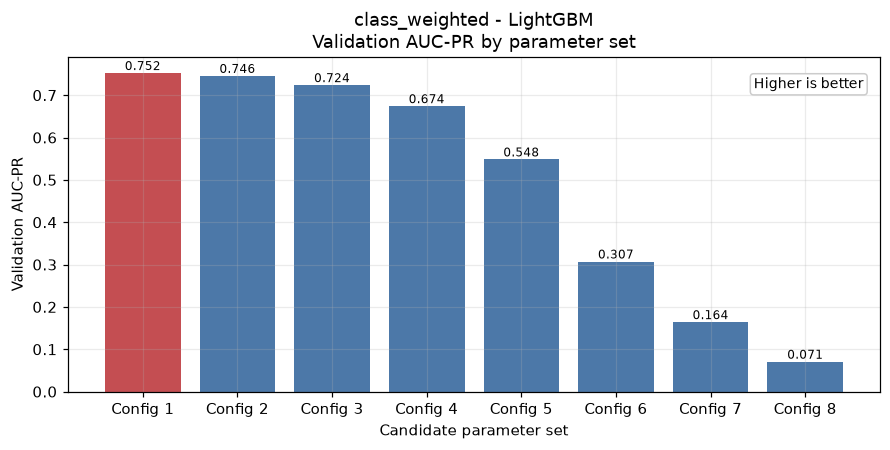

class_weighted - LightGBM: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=600, lr=0.03, leaves=31, child=200",0.7524,"53,029,720",0.0005,0.0714,0.9194,5791,445,39
1,"trees=300, lr=0.03, leaves=63, child=300",0.7456,"36,441,492",0.0005,0.0253,0.9401,17496,455,29
2,"trees=300, lr=0.03, leaves=31, child=200",0.7238,"36,295,972",0.0005,0.0239,0.9401,18550,455,29
3,"trees=600, lr=0.03, leaves=63, child=300",0.6741,"76,040,286",0.0005,0.1031,0.9091,3829,440,44
4,"trees=600, lr=0.03, leaves=15, child=300",0.5483,"91,569,624",0.0005,0.0972,0.8595,3866,416,68
5,"trees=300, lr=0.05, leaves=31, child=100",0.3072,"136,597,247",0.0005,0.1867,0.8099,1708,392,92
6,"trees=300, lr=0.05, leaves=15, child=200",0.1642,"83,998,434",0.0005,0.0451,0.8512,8719,412,72
7,"trees=100, lr=0.05, leaves=15, child=200",0.0707,"33,510,587",0.0010,0.0106,0.9050,40774,438,46


figure -> Module_08/figures/m5_tuning_class_weighted_lightgbm_val_net_cost.png


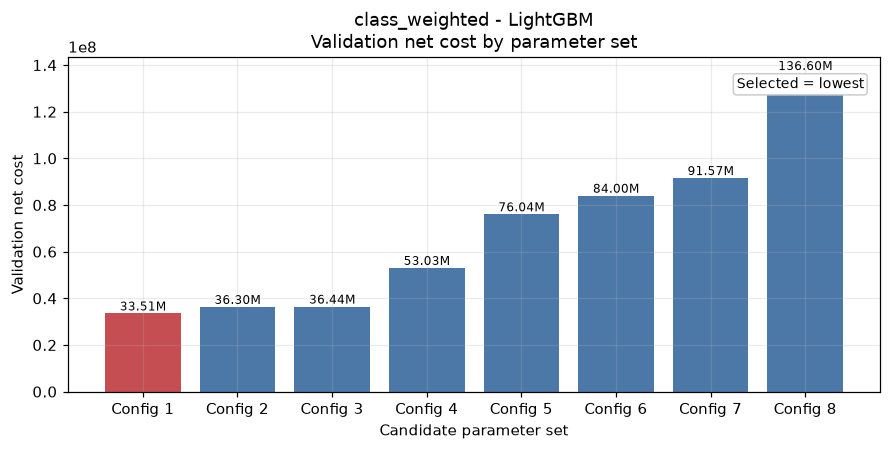

class_weighted - LightGBM: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=100, lr=0.05, leaves=15, child=200",0.0707,"33,510,587",0.0010,0.0106,0.9050,40774,438,46
1,"trees=300, lr=0.03, leaves=31, child=200",0.7238,"36,295,972",0.0005,0.0239,0.9401,18550,455,29
2,"trees=300, lr=0.03, leaves=63, child=300",0.7456,"36,441,492",0.0005,0.0253,0.9401,17496,455,29
3,"trees=600, lr=0.03, leaves=31, child=200",0.7524,"53,029,720",0.0005,0.0714,0.9194,5791,445,39
4,"trees=600, lr=0.03, leaves=63, child=300",0.6741,"76,040,286",0.0005,0.1031,0.9091,3829,440,44
5,"trees=300, lr=0.05, leaves=15, child=200",0.1642,"83,998,434",0.0005,0.0451,0.8512,8719,412,72
6,"trees=600, lr=0.03, leaves=15, child=300",0.5483,"91,569,624",0.0005,0.0972,0.8595,3866,416,68
7,"trees=300, lr=0.05, leaves=31, child=100",0.3072,"136,597,247",0.0005,0.1867,0.8099,1708,392,92


figure -> Module_08/figures/m5_tuning_smote_logisticregression_val_auc_pr.png


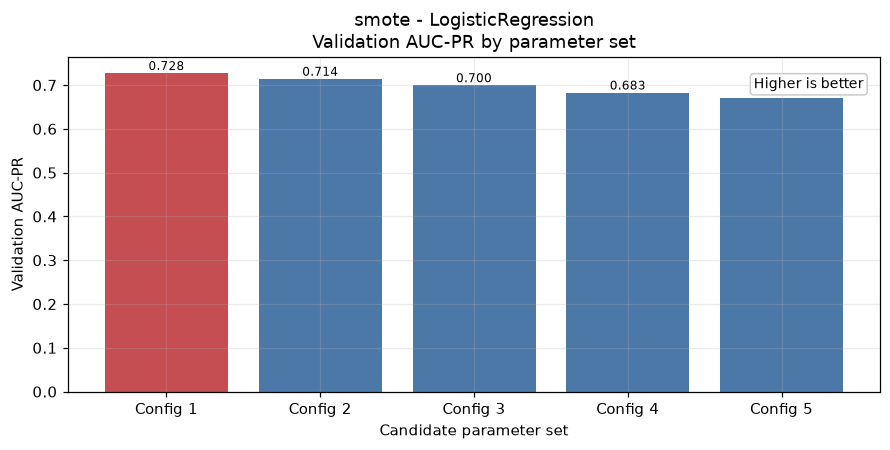

smote - LogisticRegression: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,C=0.03,0.7275,"1,440,103",0.0010,0.0044,0.9938,109794,481,3
1,C=0.1,0.7145,"8,950,054",0.0005,0.0041,0.9917,116207,480,4
2,C=0.3,0.6998,"10,176,698",0.0005,0.0045,0.9897,104845,479,5
3,C=1.0,0.6830,"10,678,312",0.0005,0.0053,0.9855,90317,477,7
4,C=3.0,0.6709,"10,628,242",0.0005,0.0056,0.9855,85310,477,7


figure -> Module_08/figures/m5_tuning_smote_logisticregression_val_net_cost.png


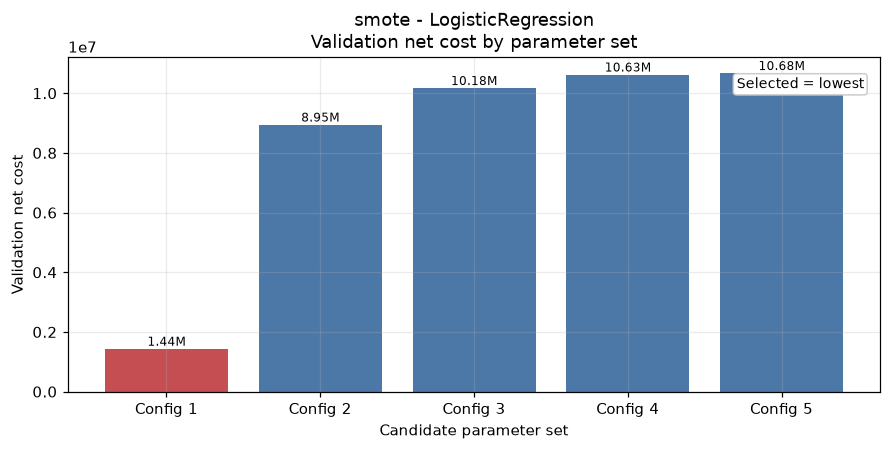

smote - LogisticRegression: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,C=0.03,0.7275,"1,440,103",0.0010,0.0044,0.9938,109794,481,3
1,C=0.1,0.7145,"8,950,054",0.0005,0.0041,0.9917,116207,480,4
2,C=0.3,0.6998,"10,176,698",0.0005,0.0045,0.9897,104845,479,5
3,C=3.0,0.6709,"10,628,242",0.0005,0.0056,0.9855,85310,477,7
4,C=1.0,0.6830,"10,678,312",0.0005,0.0053,0.9855,90317,477,7


figure -> Module_08/figures/m5_tuning_smote_randomforest_val_auc_pr.png


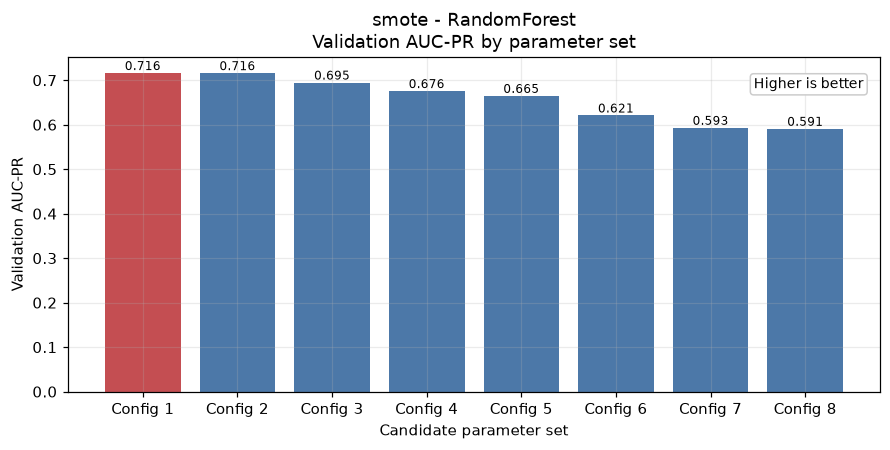

smote - RandomForest: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=200, depth=16, leaf=20",0.7163,"1,052,627",0.0015,0.0053,0.9979,89902,483,1
1,"trees=200, depth=20, leaf=20",0.7160,"1,216,510",0.0005,0.0040,1.0000,121651,484,0
2,"trees=300, depth=16, leaf=50",0.6947,"1,718,017",0.0005,0.0031,0.9979,156441,483,1
3,"trees=100, depth=12, leaf=50",0.6757,"2,034,340",0.0005,0.0024,1.0000,203434,484,0
4,"trees=50, depth=8, leaf=100",0.6648,"1,428,547",0.0030,0.0038,0.9979,127494,483,1
5,"trees=200, depth=16, leaf=50",0.6208,"3,814,385",0.0010,0.0092,0.9835,51098,476,8
6,"trees=200, depth=12, leaf=100",0.5930,"3,298,885",0.0005,0.0060,0.9917,79399,480,4
7,"trees=100, depth=16, leaf=100",0.5908,"3,728,268",0.0005,0.0064,0.9897,73860,479,5


figure -> Module_08/figures/m5_tuning_smote_randomforest_val_net_cost.png


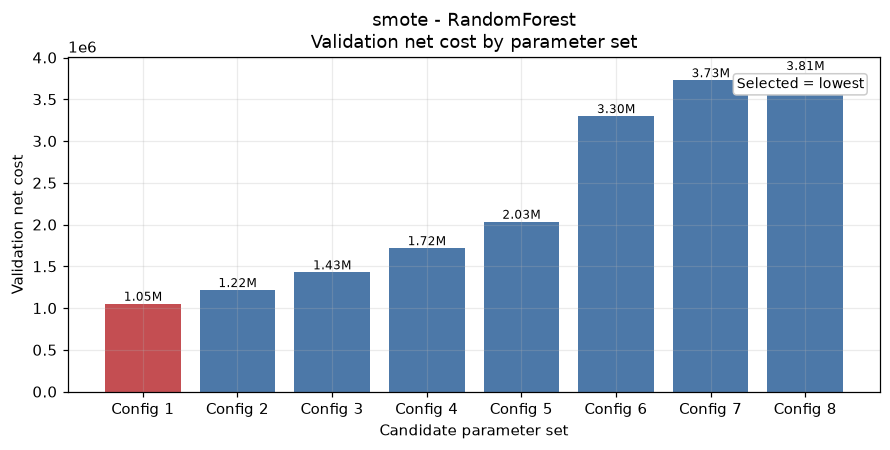

smote - RandomForest: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=200, depth=16, leaf=20",0.7163,"1,052,627",0.0015,0.0053,0.9979,89902,483,1
1,"trees=200, depth=20, leaf=20",0.7160,"1,216,510",0.0005,0.0040,1.0000,121651,484,0
2,"trees=50, depth=8, leaf=100",0.6648,"1,428,547",0.0030,0.0038,0.9979,127494,483,1
3,"trees=300, depth=16, leaf=50",0.6947,"1,718,017",0.0005,0.0031,0.9979,156441,483,1
4,"trees=100, depth=12, leaf=50",0.6757,"2,034,340",0.0005,0.0024,1.0000,203434,484,0
5,"trees=200, depth=12, leaf=100",0.5930,"3,298,885",0.0005,0.0060,0.9917,79399,480,4
6,"trees=100, depth=16, leaf=100",0.5908,"3,728,268",0.0005,0.0064,0.9897,73860,479,5
7,"trees=200, depth=16, leaf=50",0.6208,"3,814,385",0.0010,0.0092,0.9835,51098,476,8


figure -> Module_08/figures/m5_tuning_smote_lightgbm_val_auc_pr.png


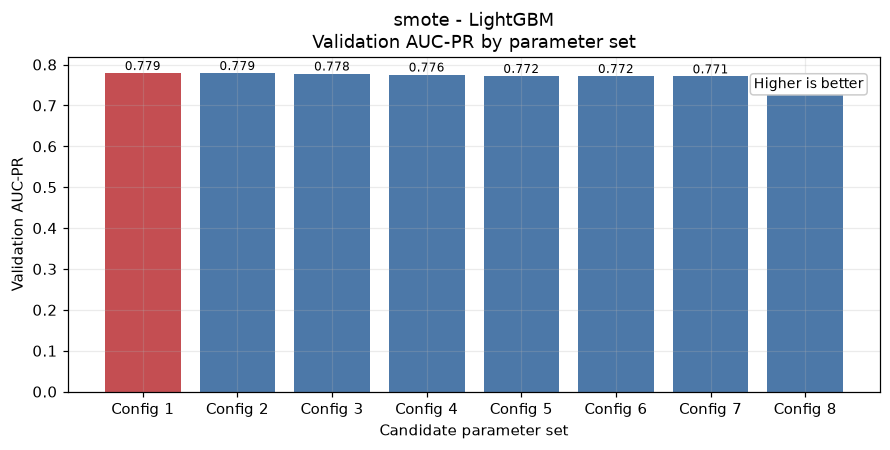

smote - LightGBM: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=600, lr=0.03, leaves=15, child=300",0.7793,"4,330,089",0.0005,0.0207,0.9793,22376,474,10
1,"trees=300, lr=0.05, leaves=15, child=200",0.7793,"3,089,200",0.0005,0.0153,0.9855,30647,477,7
2,"trees=600, lr=0.03, leaves=31, child=200",0.7780,"12,412,870",0.0005,0.0257,0.9711,17813,470,14
3,"trees=600, lr=0.03, leaves=63, child=300",0.7756,"5,188,866",0.0005,0.0223,0.9773,20761,473,11
4,"trees=300, lr=0.03, leaves=31, child=200",0.7722,"2,839,810",0.0005,0.0091,0.9897,51992,479,5
5,"trees=300, lr=0.03, leaves=63, child=300",0.7720,"3,071,867",0.0005,0.0126,0.9876,37345,478,6
6,"trees=300, lr=0.05, leaves=31, child=100",0.7712,"4,686,731",0.0005,0.0205,0.9793,22615,474,10
7,"trees=100, lr=0.05, leaves=15, child=200",0.7487,"1,190,742",0.0015,0.0041,0.9979,118053,483,1


figure -> Module_08/figures/m5_tuning_smote_lightgbm_val_net_cost.png


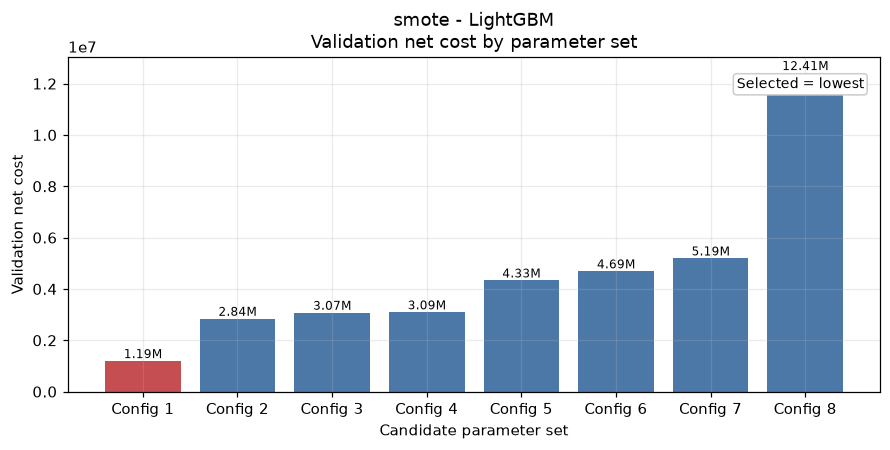

smote - LightGBM: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=100, lr=0.05, leaves=15, child=200",0.7487,"1,190,742",0.0015,0.0041,0.9979,118053,483,1
1,"trees=300, lr=0.03, leaves=31, child=200",0.7722,"2,839,810",0.0005,0.0091,0.9897,51992,479,5
2,"trees=300, lr=0.03, leaves=63, child=300",0.7720,"3,071,867",0.0005,0.0126,0.9876,37345,478,6
3,"trees=300, lr=0.05, leaves=15, child=200",0.7793,"3,089,200",0.0005,0.0153,0.9855,30647,477,7
4,"trees=600, lr=0.03, leaves=15, child=300",0.7793,"4,330,089",0.0005,0.0207,0.9793,22376,474,10
5,"trees=300, lr=0.05, leaves=31, child=100",0.7712,"4,686,731",0.0005,0.0205,0.9793,22615,474,10
6,"trees=600, lr=0.03, leaves=63, child=300",0.7756,"5,188,866",0.0005,0.0223,0.9773,20761,473,11
7,"trees=600, lr=0.03, leaves=31, child=200",0.7780,"12,412,870",0.0005,0.0257,0.9711,17813,470,14


figure -> Module_08/figures/m5_tuning_undersampling_logisticregression_val_auc_pr.png


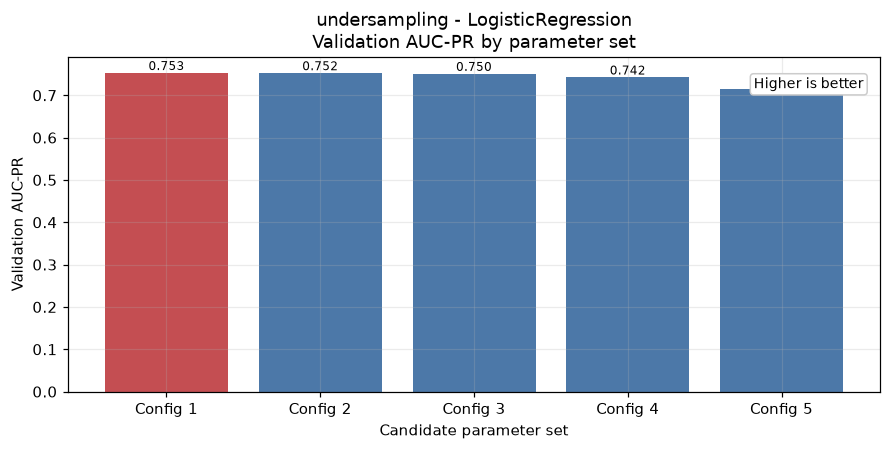

undersampling - LogisticRegression: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,C=1.0,0.7526,"1,138,113",0.0010,0.0060,0.9938,79595,481,3
1,C=3.0,0.7521,"1,269,673",0.0005,0.0052,0.9938,92751,481,3
2,C=0.3,0.7505,"1,030,013",0.0025,0.0069,0.9938,68785,481,3
3,C=0.1,0.7420,"1,122,625",0.0050,0.0068,0.9917,69615,480,4
4,C=0.03,0.7152,"1,141,845",0.0105,0.0067,0.9917,71537,480,4


figure -> Module_08/figures/m5_tuning_undersampling_logisticregression_val_net_cost.png


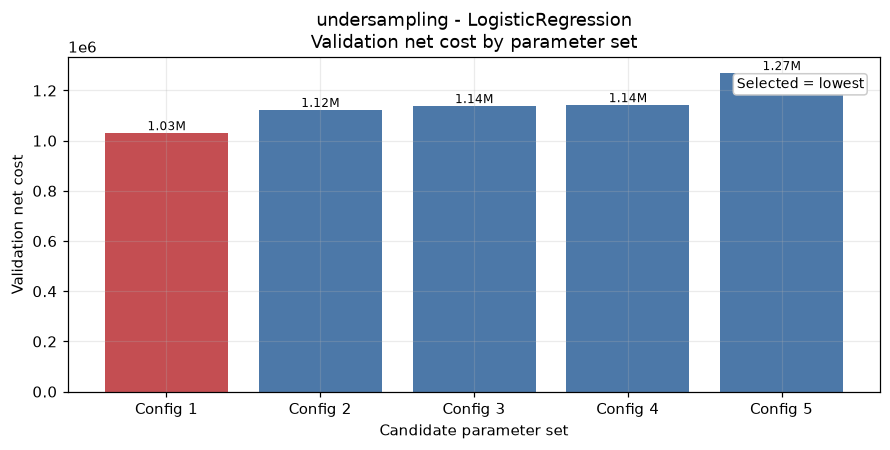

undersampling - LogisticRegression: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,C=0.3,0.7505,"1,030,013",0.0025,0.0069,0.9938,68785,481,3
1,C=0.1,0.7420,"1,122,625",0.0050,0.0068,0.9917,69615,480,4
2,C=1.0,0.7526,"1,138,113",0.0010,0.0060,0.9938,79595,481,3
3,C=0.03,0.7152,"1,141,845",0.0105,0.0067,0.9917,71537,480,4
4,C=3.0,0.7521,"1,269,673",0.0005,0.0052,0.9938,92751,481,3


figure -> Module_08/figures/m5_tuning_undersampling_randomforest_val_auc_pr.png


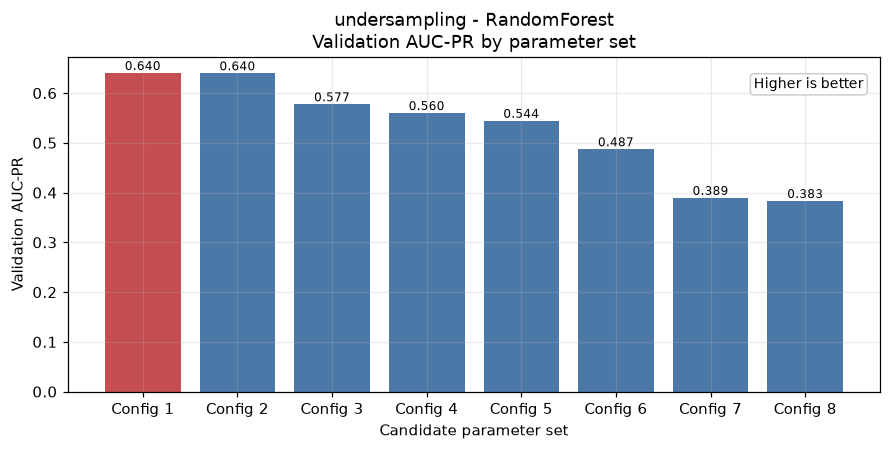

undersampling - RandomForest: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=200, depth=16, leaf=20",0.6403,"1,390,431",0.0060,0.0045,0.9959,105848,482,2
1,"trees=200, depth=20, leaf=20",0.6397,"1,389,471",0.0060,0.0045,0.9959,105752,482,2
2,"trees=300, depth=16, leaf=50",0.5774,"1,315,751",0.0120,0.0049,0.9959,98380,482,2
3,"trees=100, depth=12, leaf=50",0.5599,"1,250,441",0.0130,0.0052,0.9959,91849,482,2
4,"trees=50, depth=8, leaf=100",0.5442,"1,258,174",0.0175,0.0045,0.9979,107983,483,1
5,"trees=200, depth=16, leaf=50",0.4871,"2,844,322",0.0120,0.0088,0.9917,53961,480,4
6,"trees=200, depth=12, leaf=100",0.3893,"1,206,956",0.0045,0.0048,0.9959,100621,482,2
7,"trees=100, depth=16, leaf=100",0.3831,"1,394,386",0.0025,0.0040,0.9959,119364,482,2


figure -> Module_08/figures/m5_tuning_undersampling_randomforest_val_net_cost.png


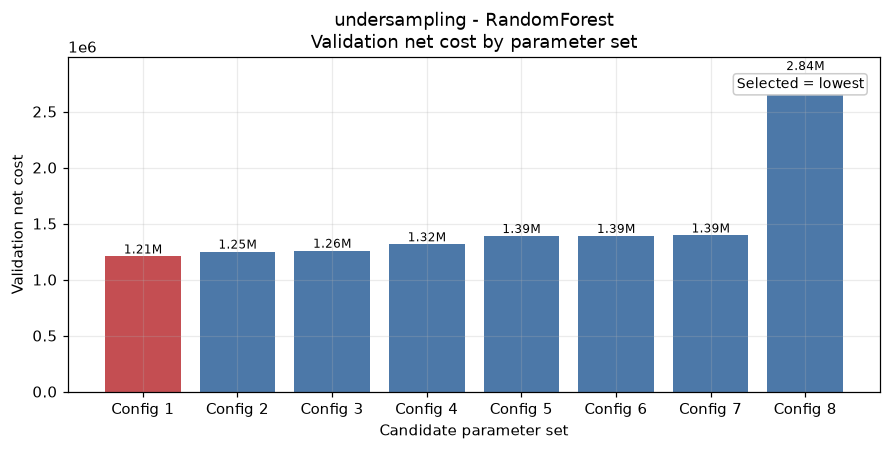

undersampling - RandomForest: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=200, depth=12, leaf=100",0.3893,"1,206,956",0.0045,0.0048,0.9959,100621,482,2
1,"trees=100, depth=12, leaf=50",0.5599,"1,250,441",0.0130,0.0052,0.9959,91849,482,2
2,"trees=50, depth=8, leaf=100",0.5442,"1,258,174",0.0175,0.0045,0.9979,107983,483,1
3,"trees=300, depth=16, leaf=50",0.5774,"1,315,751",0.0120,0.0049,0.9959,98380,482,2
4,"trees=200, depth=20, leaf=20",0.6397,"1,389,471",0.0060,0.0045,0.9959,105752,482,2
5,"trees=200, depth=16, leaf=20",0.6403,"1,390,431",0.0060,0.0045,0.9959,105848,482,2
6,"trees=100, depth=16, leaf=100",0.3831,"1,394,386",0.0025,0.0040,0.9959,119364,482,2
7,"trees=200, depth=16, leaf=50",0.4871,"2,844,322",0.0120,0.0088,0.9917,53961,480,4


figure -> Module_08/figures/m5_tuning_undersampling_lightgbm_val_auc_pr.png


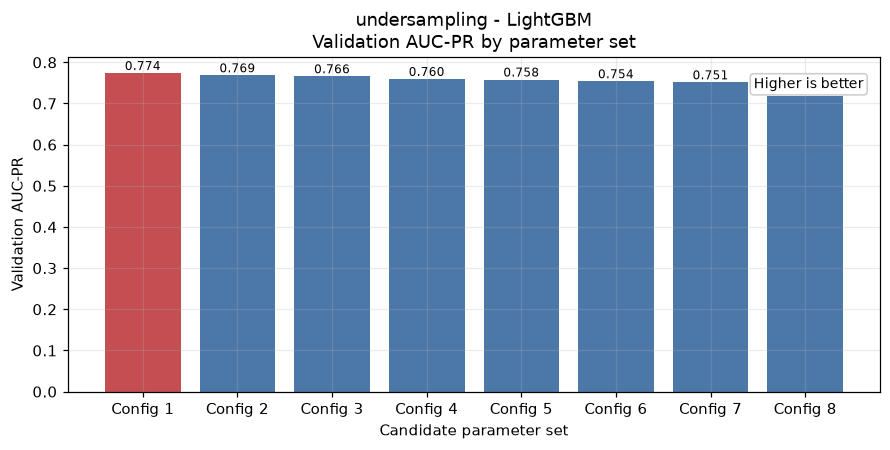

undersampling - LightGBM: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=600, lr=0.03, leaves=15, child=300",0.7740,"964,467",0.0005,0.0059,0.9979,81086,483,1
1,"trees=300, lr=0.05, leaves=15, child=200",0.7685,"902,993",0.0020,0.0085,0.9938,56083,481,3
2,"trees=600, lr=0.03, leaves=31, child=200",0.7662,"930,643",0.0015,0.0081,0.9938,58848,481,3
3,"trees=600, lr=0.03, leaves=63, child=300",0.7597,"947,827",0.0015,0.0060,0.9979,79422,483,1
4,"trees=300, lr=0.03, leaves=31, child=200",0.7582,"912,910",0.0020,0.0053,1.0000,91291,484,0
5,"trees=300, lr=0.03, leaves=63, child=300",0.7540,"964,630",0.0020,0.0050,1.0000,96463,484,0
6,"trees=300, lr=0.05, leaves=31, child=100",0.7515,"806,791",0.0025,0.0106,0.9917,44945,480,4
7,"trees=100, lr=0.05, leaves=15, child=200",0.7183,"1,079,890",0.0040,0.0045,1.0000,107989,484,0


figure -> Module_08/figures/m5_tuning_undersampling_lightgbm_val_net_cost.png


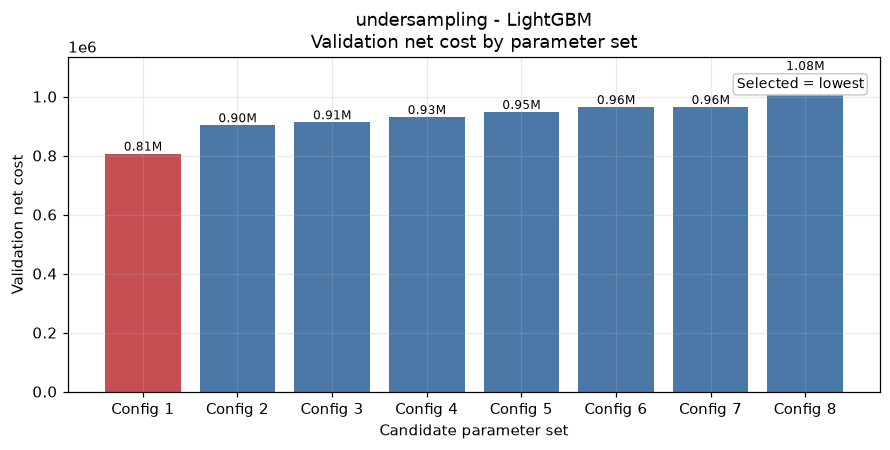

undersampling - LightGBM: validation config mapping


,config_label,val_auc_pr,val_net_cost,val_threshold,val_precision,val_recall,val_n_fp,val_n_tp,val_n_fn
0,"trees=300, lr=0.05, leaves=31, child=100",0.7515,"806,791",0.0025,0.0106,0.9917,44945,480,4
1,"trees=300, lr=0.05, leaves=15, child=200",0.7685,"902,993",0.0020,0.0085,0.9938,56083,481,3
2,"trees=300, lr=0.03, leaves=31, child=200",0.7582,"912,910",0.0020,0.0053,1.0000,91291,484,0
3,"trees=600, lr=0.03, leaves=31, child=200",0.7662,"930,643",0.0015,0.0081,0.9938,58848,481,3
4,"trees=600, lr=0.03, leaves=63, child=300",0.7597,"947,827",0.0015,0.0060,0.9979,79422,483,1
5,"trees=600, lr=0.03, leaves=15, child=300",0.7740,"964,467",0.0005,0.0059,0.9979,81086,483,1
6,"trees=300, lr=0.03, leaves=63, child=300",0.7540,"964,630",0.0020,0.0050,1.0000,96463,484,0
7,"trees=100, lr=0.05, leaves=15, child=200",0.7183,"1,079,890",0.0040,0.0045,1.0000,107989,484,0


Validation AUC-PR table only:


,data_balancing,model,config_label,val_auc_pr
37,class_weighted,LightGBM,"trees=600, lr=0.03, leaves=31, child=200",0.7524
38,class_weighted,LightGBM,"trees=300, lr=0.03, leaves=63, child=300",0.7456
36,class_weighted,LightGBM,"trees=300, lr=0.03, leaves=31, child=200",0.7238
41,class_weighted,LightGBM,"trees=600, lr=0.03, leaves=63, child=300",0.6741
39,class_weighted,LightGBM,"trees=600, lr=0.03, leaves=15, child=300",0.5483
40,class_weighted,LightGBM,"trees=300, lr=0.05, leaves=31, child=100",0.3072
35,class_weighted,LightGBM,"trees=300, lr=0.05, leaves=15, child=200",0.1642
34,class_weighted,LightGBM,"trees=100, lr=0.05, leaves=15, child=200",0.0707
21,class_weighted,LogisticRegression,C=0.03,0.7482
22,class_weighted,LogisticRegression,C=0.1,0.7460


Validation net-cost table only:


,data_balancing,model,config_label,val_net_cost
34,class_weighted,LightGBM,"trees=100, lr=0.05, leaves=15, child=200","33,510,587"
36,class_weighted,LightGBM,"trees=300, lr=0.03, leaves=31, child=200","36,295,972"
38,class_weighted,LightGBM,"trees=300, lr=0.03, leaves=63, child=300","36,441,492"
37,class_weighted,LightGBM,"trees=600, lr=0.03, leaves=31, child=200","53,029,720"
41,class_weighted,LightGBM,"trees=600, lr=0.03, leaves=63, child=300","76,040,286"
35,class_weighted,LightGBM,"trees=300, lr=0.05, leaves=15, child=200","83,998,434"
39,class_weighted,LightGBM,"trees=600, lr=0.03, leaves=15, child=300","91,569,624"
40,class_weighted,LightGBM,"trees=300, lr=0.05, leaves=31, child=100","136,597,247"
25,class_weighted,LogisticRegression,C=3.0,"1,057,192"
24,class_weighted,LogisticRegression,C=1.0,"1,058,482"


In [27]:
def plot_tuning_metric(data_balancing, model_name, metric, ylabel, filename_suffix, lower_is_better):
    sub = tuning_results[(tuning_results['data_balancing'] == data_balancing) & (tuning_results['model'] == model_name)].copy()
    if sub.empty:
        return
    sub = sub.sort_values(metric, ascending=lower_is_better).reset_index(drop=True)
    labels = [f'Config {i+1}' for i in range(len(sub))]
    colors = ['#C44E52'] + ['#4C78A8'] * (len(sub) - 1)
    fig, ax = plt.subplots(figsize=(8.2, 4.2))
    ax.bar(labels, sub[metric], color=colors)
    title_metric = 'Validation net cost' if metric == 'val_net_cost' else 'Validation AUC-PR'
    ax.set_title(f'{data_balancing} - {model_name}\n{title_metric} by parameter set')
    ax.set_xlabel('Candidate parameter set')
    ax.set_ylabel(ylabel)
    for i, value in enumerate(sub[metric]):
        label = f'{value/1_000_000:.2f}M' if 'cost' in metric else f'{value:.3f}'
        ax.text(i, value, label, ha='center', va='bottom', fontsize=8)
    note = 'Selected = lowest' if lower_is_better else 'Higher is better'
    ax.text(0.98, 0.94, note, transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox={'boxstyle': 'round,pad=0.25', 'facecolor': 'white', 'edgecolor': '#CCCCCC'})
    fig.tight_layout()
    save_fig(fig, f'm5_tuning_{data_balancing}_{model_name.lower()}_{filename_suffix}')
    plt.show()

    print(f'{data_balancing} - {model_name}: validation config mapping')
    display(sub[['config_label', 'val_auc_pr', 'val_net_cost', 'val_threshold', 'val_precision', 'val_recall', 'val_n_fp', 'val_n_tp', 'val_n_fn']].style.format({
        'val_auc_pr': '{:.4f}',
        'val_net_cost': '{:,.0f}',
        'val_threshold': '{:.4f}',
        'val_precision': '{:.4f}',
        'val_recall': '{:.4f}',
    }))


for _method in BALANCING_METHODS:
    for _model in MODEL_NAMES:
        plot_tuning_metric(_method, _model, 'val_auc_pr', 'Validation AUC-PR', 'val_auc_pr', lower_is_better=False)
        plot_tuning_metric(_method, _model, 'val_net_cost', 'Validation net cost', 'val_net_cost', lower_is_better=True)

print('Validation AUC-PR table only:')
display(val_aucpr_table.sort_values(['data_balancing', 'model', 'val_auc_pr'], ascending=[True, True, False]).style.format({'val_auc_pr': '{:.4f}'}))

print('Validation net-cost table only:')
display(val_netcost_table.sort_values(['data_balancing', 'model', 'val_net_cost'], ascending=[True, True, True]).style.format({'val_net_cost': '{:,.0f}'}))


## 3. Select on validation, then refit one locked model

All decisions are completed before the test set is opened:

1. Choose hyperparameters, balancing strategy, model family, and threshold on validation.
2. Refit only that locked model on the full Module 4 train set.
3. Apply the frozen validation threshold to test exactly once.

The validation winner is the candidate with the lowest validation net cost; validation
AUC-PR breaks ties. Test metrics never feed back into model or threshold selection.

In [28]:
MODEL_CACHE = MODELS / 'm5_model_cache'
MODEL_CACHE.mkdir(parents=True, exist_ok=True)

# Lock the complete decision using validation only.
selected_val = (best_tuning
    .sort_values(['val_net_cost', 'val_auc_pr'], ascending=[True, False])
    .iloc[0])

best_method = selected_val['data_balancing']
best_name = selected_val['model']
t_star = float(selected_val['val_threshold'])
best_cols = MODEL_FEATURES

params = dict(TUNED_MODEL_PARAMS[(best_method, best_name)])
if 'n_jobs' in params:
    params['n_jobs'] = TUNE_N_JOBS

X_full_base = X_train[MODEL_FEATURES]
y_full_base = y_train.astype(int)
X_fit, y_fit = apply_balancing(
    X_full_base, y_full_base, best_method, seed=TUNE_RANDOM_STATE
)

print('LOCKED ON VALIDATION')
display(pd.DataFrame([{
    'data_balancing': best_method,
    'model': best_name,
    'val_auc_pr': selected_val['val_auc_pr'],
    'val_threshold': t_star,
    'val_precision': selected_val['val_precision'],
    'val_recall': selected_val['val_recall'],
    'val_net_cost': selected_val['val_net_cost'],
}]).style.format({
    'val_auc_pr': '{:.4f}',
    'val_threshold': '{:.4f}',
    'val_precision': '{:.2%}',
    'val_recall': '{:.2%}',
    'val_net_cost': '{:,.0f}',
}))

print(
    f"refit full train | {best_method} | {best_name} | "
    f"rows {len(y_full_base):,} -> {len(y_fit):,}"
)
best_model = make_candidate_model(best_name, params)
best_model.fit(X_fit, y_fit)
best_p = best_model.predict_proba(X_test[MODEL_FEATURES])[:, 1]

model_path = MODEL_CACHE / f'behavioural_{best_method}_{best_name}.joblib'
joblib.dump(best_model, model_path)
proba = {(best_method, best_name): best_p}
model_paths = {(best_method, best_name): model_path}

save_table(
    best_tuning.assign(
        selected_for_test=lambda d: (
            (d['data_balancing'] == best_method) & (d['model'] == best_name)
        )
    ),
    'm5_validation_model_selection_clean',
    index=False,
)
print('test remains unopened for selection; one locked model is now ready for evaluation')

LOCKED ON VALIDATION


,data_balancing,model,val_auc_pr,val_threshold,val_precision,val_recall,val_net_cost
0,undersampling,LightGBM,0.7515,0.0025,1.06%,99.17%,"806,791"


refit full train | undersampling | LightGBM | rows 2,217,905 -> 83,055
table  -> Module_08/m5_validation_model_selection_clean.csv
test remains unopened for selection; one locked model is now ready for evaluation


## 4. Final test evaluation: one model, one frozen threshold

The test set is used once. We calculate AUC-PR from the model scores and calculate
precision, recall, false alerts, review load, and net cost at the threshold already
selected on validation. There is no threshold sweep and no model comparison on test.

In [29]:
from sklearn.metrics import confusion_matrix

# No test-set threshold sweep: use the validation threshold unchanged.
pred = best_p >= t_star
tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
missed_fraud_amount = float(
    amount_test[(y_test.values == 1) & (~pred)].sum()
)
fraud_amount_caught = float(
    amount_test[(y_test.values == 1) & pred].sum()
)

test_results = pd.DataFrame([{
    'selection_source': 'validation_15',
    'feature_set': 'behavioural',
    'data_balancing': best_method,
    'model': best_name,
    'threshold_source': 'validation_15',
    'threshold': t_star,
    'test_rows': len(y_test),
    'test_fraud_rows': int(y_test.sum()),
    'test_prevalence_pct': y_test.mean() * 100,
    'test_auc_pr': average_precision_score(y_test, best_p),
    'test_precision': precision_score(y_test, pred, zero_division=0),
    'test_recall': recall_score(y_test, pred, zero_division=0),
    'test_f1': f1_score(y_test, pred, zero_division=0),
    'test_tp': int(tp),
    'test_fn': int(fn),
    'test_fp': int(fp),
    'test_tn': int(tn),
    'test_review_queue': int(pred.sum()),
    'test_review_rate_pct': pred.mean() * 100,
    'test_fraud_amount_caught': fraud_amount_caught,
    'test_fraud_amount_missed': missed_fraud_amount,
    'c_fp_assumption': C_FP,
    'test_net_cost': missed_fraud_amount + C_FP * fp,
}])

display(test_results.style.format({
    'threshold': '{:.4f}',
    'test_prevalence_pct': '{:.3f}%',
    'test_auc_pr': '{:.4f}',
    'test_precision': '{:.2%}',
    'test_recall': '{:.2%}',
    'test_f1': '{:.4f}',
    'test_review_rate_pct': '{:.2f}%',
    'test_fraud_amount_caught': '{:,.0f}',
    'test_fraud_amount_missed': '{:,.0f}',
    'test_net_cost': '{:,.0f}',
}))
save_table(test_results, 'm5_final_test_result_clean', index=False)
print('Test was evaluated once with the validation decision frozen.')

,selection_source,feature_set,data_balancing,model,threshold_source,threshold,test_rows,test_fraud_rows,test_prevalence_pct,test_auc_pr,test_precision,test_recall,test_f1,test_tp,test_fn,test_fp,test_tn,test_review_queue,test_review_rate_pct,test_fraud_amount_caught,test_fraud_amount_missed,c_fp_assumption,test_net_cost
0,validation_15,behavioural,undersampling,LightGBM,validation_15,0.0025,552504,4258,0.771%,0.8600,5.15%,98.90%,0.0979,4211,47,77562,470684,81773,14.80%,"6,645,318,602","57,276,164",10.000000,"58,051,784"


table  -> Module_08/m5_final_test_result_clean.csv
Test was evaluated once with the validation decision frozen.


## 5. Validation selection and final-test visualization

The validation chart compares ranking quality before test. The test chart reports only
the locked winner and does not compare alternatives.

figure -> Module_08/figures/m5_validation_auc_pr_clean_selection.png


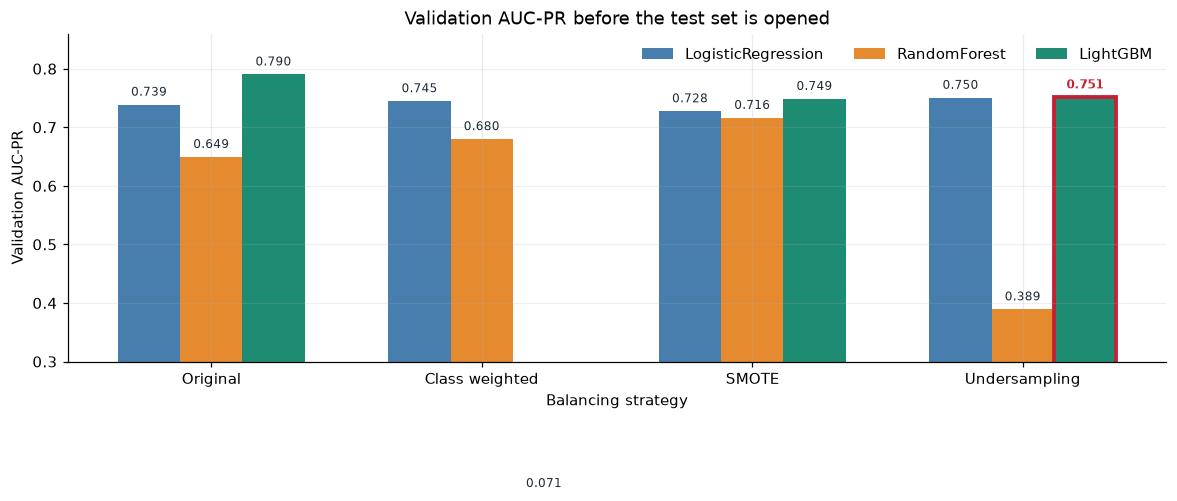

figure -> Module_08/figures/m5_final_test_locked_model_counts.png


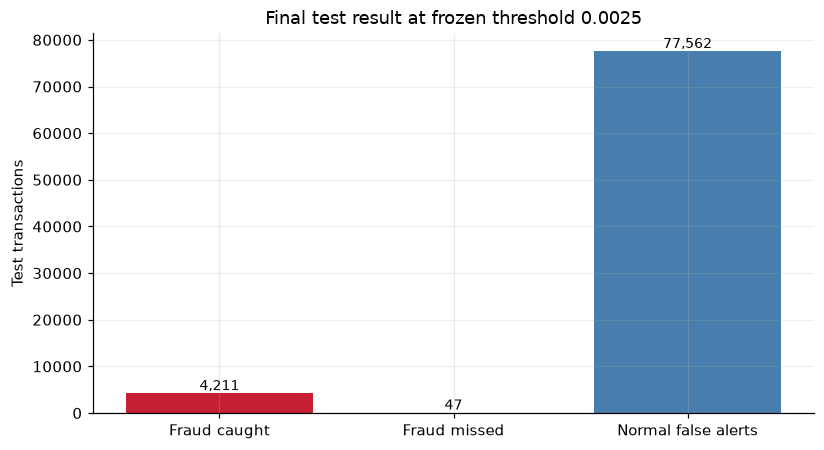

In [30]:
# Validation AUC-PR: all candidates are compared before test.
val_plot = best_tuning.copy()
method_order = ['original', 'class_weighted', 'smote', 'undersampling']
model_order = ['LogisticRegression', 'RandomForest', 'LightGBM']
colors = {
    'LogisticRegression': '#477EAD',
    'RandomForest': '#E58A2F',
    'LightGBM': '#1E8C73',
}

fig, ax = plt.subplots(figsize=(10.8, 5.0))
x = np.arange(len(method_order))
width = 0.23
for offset, model_name in enumerate(model_order):
    values = [
        float(val_plot[
            (val_plot['data_balancing'] == method)
            & (val_plot['model'] == model_name)
        ]['val_auc_pr'].iloc[0])
        for method in method_order
    ]
    positions = x + (offset - 1) * width
    bars = ax.bar(positions, values, width, color=colors[model_name], label=model_name)
    for bar, value, method in zip(bars, values, method_order):
        selected = method == best_method and model_name == best_name
        if selected:
            bar.set_edgecolor('#C52035')
            bar.set_linewidth(2.5)
        ax.text(
            bar.get_x() + bar.get_width()/2, value + 0.01, f'{value:.3f}',
            ha='center', va='bottom', fontsize=8,
            color='#C52035' if selected else '#1F2A37',
            fontweight='bold' if selected else 'normal',
        )
ax.set_ylim(0.30, 0.86)
ax.set_ylabel('Validation AUC-PR')
ax.set_xlabel('Balancing strategy')
ax.set_xticks(x)
ax.set_xticklabels(['Original', 'Class weighted', 'SMOTE', 'Undersampling'])
ax.set_title('Validation AUC-PR before the test set is opened')
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(ncol=3, frameon=False)
fig.tight_layout()
save_fig(fig, 'm5_validation_auc_pr_clean_selection')
plt.show()

# One final-test figure: case counts at the frozen validation threshold.
count_labels = ['Fraud caught', 'Fraud missed', 'Normal false alerts']
count_values = [
    int(test_results.iloc[0]['test_tp']),
    int(test_results.iloc[0]['test_fn']),
    int(test_results.iloc[0]['test_fp']),
]
fig, ax = plt.subplots(figsize=(7.6, 4.2))
bars = ax.bar(count_labels, count_values, color=['#C52035', '#F0A202', '#477EAD'])
for bar, value in zip(bars, count_values):
    ax.text(bar.get_x() + bar.get_width()/2, value, f'{value:,}',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Test transactions')
ax.set_title(f'Final test result at frozen threshold {t_star:.4f}')
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_fig(fig, 'm5_final_test_locked_model_counts')
plt.show()

## 6. Review-budget analysis for the selected model

This raw-count view ignores the `C_FP` formula and simply asks: if analysts review the
top-risk transactions, how many are fraud and how many are normal false positives?


,review_budget_pct,flagged_rows,fraud_caught,false_positive_normals,precision,fraud_recall
0,0.1%,553,552,1,99.8%,13.0%
1,0.2%,1106,1103,3,99.7%,25.9%
2,0.5%,2763,2599,164,94.1%,61.0%
3,1.0%,5526,3625,1901,65.6%,85.1%
4,2.0%,11051,3979,7072,36.0%,93.4%
5,5.0%,27626,4122,23504,14.9%,96.8%


table  -> Module_08/review_budget_analysis.csv
figure -> Module_08/figures/m5_review_budget_queue_selected_model.png


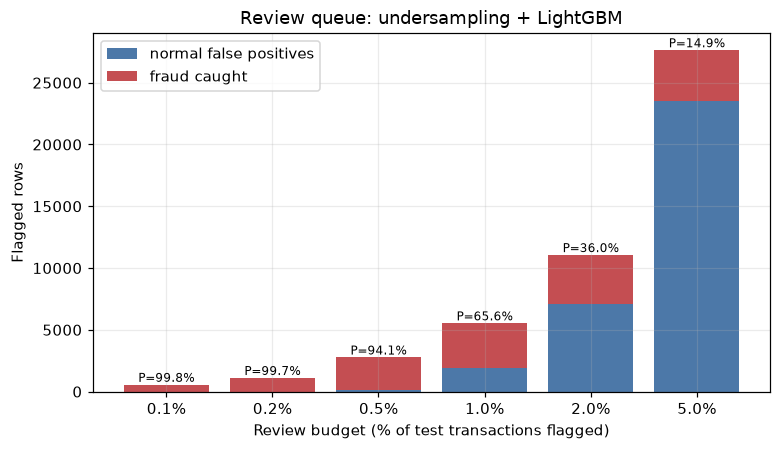

In [31]:
best_p = proba[(best_method, best_name)]
budgets = np.array([0.001, 0.002, 0.005, 0.010, 0.020, 0.050])
order = np.argsort(best_p)[::-1]
rows = []
for budget in budgets:
    k = max(1, int(np.ceil(len(y_test) * budget)))
    flagged_idx = order[:k]
    fraud_caught = int(y_test.iloc[flagged_idx].sum())
    false_pos = int(k - fraud_caught)
    rows.append({
        'review_budget_pct': budget * 100,
        'flagged_rows': k,
        'fraud_caught': fraud_caught,
        'false_positive_normals': false_pos,
        'precision': fraud_caught / k,
        'fraud_recall': fraud_caught / int(y_test.sum()),
    })
review_budget = pd.DataFrame(rows)
display(review_budget.style.format({
    'review_budget_pct': '{:.1f}%',
    'precision': '{:.1%}',
    'fraud_recall': '{:.1%}',
}))
save_table(review_budget, 'review_budget_analysis', index=False)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.arange(len(review_budget))
ax.bar(x, review_budget['false_positive_normals'], label='normal false positives', color='#4C78A8')
ax.bar(x, review_budget['fraud_caught'], bottom=review_budget['false_positive_normals'], label='fraud caught', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels([f"{v:.1f}%" for v in review_budget['review_budget_pct']])
ax.set_xlabel('Review budget (% of test transactions flagged)')
ax.set_ylabel('Flagged rows')
ax.set_title(f'Review queue: {best_method} + {best_name}')
ax.legend()
for i, row in review_budget.iterrows():
    ax.text(i, row['flagged_rows'], f"P={row['precision']:.1%}", ha='center', va='bottom', fontsize=8)
fig.tight_layout()
save_fig(fig, 'm5_review_budget_queue_selected_model')
plt.show()


## 6.1 Policy view: top-risk queue composition

This chart translates model scores into a risk-policy question: among the top-risk transactions,
how many are true fraud and how many are normal false alerts?

If even the strictest top-risk slice has low precision, the model should be used for **manual review
priority**, not automatic blocking.

,review_rate_pct,k_transactions,precision_at_k,recall_at_k,fraud_amount_recall_at_k,fraud_cases_caught_at_k,normal_false_alerts_at_k
0,0.1%,553,99.8%,13.0%,11.9%,552,1
1,0.2%,1106,99.7%,25.9%,25.2%,1103,3
2,0.5%,2763,94.1%,61.0%,61.5%,2599,164
3,1.0%,5526,65.6%,85.1%,87.5%,3625,1901
4,2.0%,11051,36.0%,93.4%,94.3%,3979,7072


table  -> Module_08/m5_test_set_review_capacity.csv
figure -> Module_08/figures/m5_policy_review_queue_composition.png


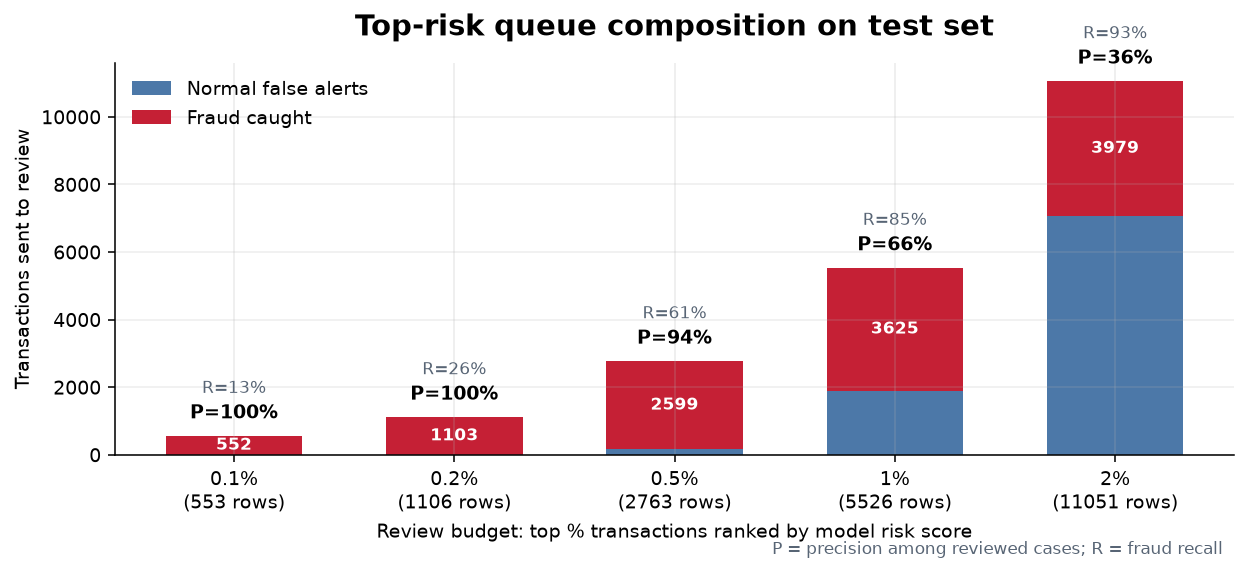

Policy insight: top 0.1% contains 552 fraud and 1 normal transactions (precision=99.8%). This supports manual review prioritization, not automatic blocking yet.


In [32]:
# Policy-friendly queue composition for slide/report discussion.
# This uses the selected behavioural model and the untouched test set.
policy_budgets = np.array([0.001, 0.002, 0.005, 0.010, 0.020])
order = np.argsort(best_p)[::-1]
policy_rows = []

total_fraud_cases = int(y_test.sum())
total_fraud_amount = float(amount_test[y_test.values == 1].sum())

for budget in policy_budgets:
    k = max(1, int(np.ceil(len(y_test) * budget)))
    flagged_idx = order[:k]
    y_flagged = y_test.iloc[flagged_idx].astype(int).to_numpy()
    fraud_caught = int(y_flagged.sum())
    normal_false_alerts = int(k - fraud_caught)
    fraud_amount_caught = float(amount_test[flagged_idx][y_flagged == 1].sum())
    policy_rows.append({
        'review_rate_pct': budget * 100,
        'k_transactions': k,
        'precision_at_k': fraud_caught / k,
        'recall_at_k': fraud_caught / total_fraud_cases,
        'fraud_amount_recall_at_k': fraud_amount_caught / total_fraud_amount,
        'fraud_cases_caught_at_k': fraud_caught,
        'normal_false_alerts_at_k': normal_false_alerts,
    })

policy_queue = pd.DataFrame(policy_rows)
display(policy_queue.style.format({
    'review_rate_pct': '{:.1f}%',
    'precision_at_k': '{:.1%}',
    'recall_at_k': '{:.1%}',
    'fraud_amount_recall_at_k': '{:.1%}',
}))
save_table(policy_queue, 'm5_test_set_review_capacity', index=False)

fig, ax = plt.subplots(figsize=(9.2, 4.7), dpi=140)
x = np.arange(len(policy_queue))
ax.bar(x, policy_queue['normal_false_alerts_at_k'], color='#4C78A8', label='Normal false alerts', width=0.62)
ax.bar(x, policy_queue['fraud_cases_caught_at_k'], bottom=policy_queue['normal_false_alerts_at_k'], color='#C52035', label='Fraud caught', width=0.62)

for i, row in policy_queue.iterrows():
    total = row['k_transactions']
    ax.text(i, total + policy_queue['k_transactions'].max() * 0.035,
            f"P={row['precision_at_k']:.0%}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.text(i, total + policy_queue['k_transactions'].max() * 0.105,
            f"R={row['recall_at_k']:.0%}", ha='center', va='bottom', fontsize=8.5, color='#586575')
    if row['fraud_cases_caught_at_k'] >= 8:
        ax.text(i, row['normal_false_alerts_at_k'] + row['fraud_cases_caught_at_k'] / 2,
                f"{int(row['fraud_cases_caught_at_k'])}", ha='center', va='center', fontsize=8.5,
                fontweight='bold', color='white')

ax.set_title('Top-risk queue composition on test set', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Review budget: top % transactions ranked by model risk score')
ax.set_ylabel('Transactions sent to review')
ax.set_xticks(x)
ax.set_xticklabels([f"{v:g}%\n({int(k)} rows)" for v, k in zip(policy_queue['review_rate_pct'], policy_queue['k_transactions'])])
ax.grid(axis='y', alpha=0.22)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', frameon=False)
ax.text(0.99, -0.22, 'P = precision among reviewed cases; R = fraud recall',
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5, color='#586575')
fig.tight_layout(rect=[0.02, 0.03, 1, 0.96])
save_fig(fig, 'm5_policy_review_queue_composition')
plt.show()

strict = policy_queue.iloc[0]
print(
    f"Policy insight: top {strict['review_rate_pct']:.1f}% contains "
    f"{int(strict['fraud_cases_caught_at_k'])} fraud and "
    f"{int(strict['normal_false_alerts_at_k'])} normal transactions "
    f"(precision={strict['precision_at_k']:.1%}). "
    "This supports manual review prioritization, not automatic blocking yet."
)

## 7. Persist the selected behavioural model

The saved policy includes model family, balancing strategy, selected threshold, net-cost
assumption, and behavioural feature list.


In [33]:
joblib.dump(best_model, MODELS / 'best_model.joblib')
metrics_row = test_results.iloc[0].to_dict()
policy = {
    'model': best_name,
    'data_balancing': best_method,
    'feature_set': 'behavioural',
    'threshold': round(t_star, 4),
    'threshold_selection': 'minimum net cost on validation_15; test evaluated once',
    'cost_model': {
        'C_fn': 'missed fraud transaction amount from amount_raw',
        'C_fp': C_FP,
        'formula': 'net_cost = missed_fraud_amount + C_fp * false_positives',
    },
    'metrics_at_threshold': metrics_row,
    'features': best_cols,
    'label': LABEL,
    'note': 'Model, balancing, hyperparameters, and threshold were locked before test.'
}
(MODELS / 'decision_threshold.json').write_text(
    json.dumps(policy, indent=2, default=float)
)
print(f"saved -> {(MODELS/'best_model.joblib').relative_to(ROOT)}")
print(f"saved -> {(MODELS/'decision_threshold.json').relative_to(ROOT)}")
print(json.dumps({
    k: policy[k]
    for k in ['model', 'data_balancing', 'feature_set', 'threshold', 'threshold_selection']
}, indent=2, default=float))

saved -> models/best_model.joblib
saved -> models/decision_threshold.json
{
  "model": "LightGBM",
  "data_balancing": "undersampling",
  "feature_set": "behavioural",
  "threshold": 0.0025,
  "threshold_selection": "minimum net cost on validation_15; test evaluated once"
}


## 8. Notes & limitations

- Only behavioural features are trained in this Module 5 path.
- Four balancing strategies are compared on validation: original, class-weighted, SMOTE, and undersampling.
- SMOTE and undersampling are applied only to training data, never validation or test.
- Hyperparameters, balancing, model family, and threshold are selected on the inner 15% validation period.
- Only the locked winner is refit on the full 80% train set and evaluated once on the untouched 20% test set.
- `C_FP = 10` is an explicit operating assumption, not a dataset fact.
- The frozen threshold can require later probability calibration because refitting may shift score calibration.